<a href="https://colab.research.google.com/github/patilshan/Projects/blob/main/Solar_PV_System_Performance_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solar PV System Performance Analysis

## Introduction

This project presents an end-to-end solar performance monitoring and diagnostic framework for three real-world photovoltaic (PV) systems located at the **Andre Agassi Preparatory Academy** in Las Vegas, Nevada. The systems are rooftop-mounted and differ in size, tilt, and inverter configuration.

 Used high-frequency (sub-hourly) time-series data from the **NREL PVDAQ dataset**, perform rigorous data cleaning and engineering, and apply multiple diagnostic flags to identify underperformance issues such as inverter faults, shading/soiling, sensor malfunctions, and data gaps. The final results are prepared in a format that is suitable for integration with visualization tools like Power BI.

---

## Objectives

- Clean and standardize raw sub-hourly PV system data.
- Calculate key performance metrics: **actual energy**, **expected energy**, and **performance ratio (PR)**.
- Detect performance anomalies using automated flagging logic, including:
  - Inverter temperature and error codes
  - Low PR during high irradiance
  - AC power dropouts under normal sun
  - Sensor data issues (e.g., stuck POA values)
  - Missing data intervals and abnormal power spikes
- Compare system-level performance to identify relative underperformance.
- Visualize trends and flag summaries in an analyst-friendly, export-ready format.
- Structure all outputs for transparency, reproducibility, and extensibility.

---

## Why This Matters

As solar deployment expands, **automated monitoring** is crucial for maintaining uptime and reducing performance losses.

It helps answer practical operational questions like:

- “Why is system 1276 underperforming in January?”
- “Can we spot inverter overheating before failure?”
- “How do PR trends differ between systems with different sizes?”
- “Is a stuck irradiance sensor distorting our KPIs?”

---

## Data Description

- **Source:** PVDAQ (Open Energy Data Initiative - NREL)
- **Resolution:** Sub-hourly (10–30 minute intervals)
- **Time Range:** January 01, 2019 – December 31, 2019
- **Format:** CSV
- **Timezone:** America/Los_Angeles (UTC-8)
- **Sensor Channels:** AC/DC power, inverter temperature, irradiance (POA/GHI), module temp, wind, timestamps, etc.

---

## PV System Overview

| System ID | Building | Size (kW) | Tilt (°) | Azimuth (°) | Years of Data | Clipping Detected | Quality Score |
|-----------|----------|-----------|----------|-------------|----------------|-------------------|----------------|
| 1276 | Building B | 68.48 | 5 | 180 | 8.9 | No | 0.19 |
| 1277 | Building C | 40.56 | 10 | 180 | 8.9 | No | 0.17 |
| 1278 | Building D | 171.36 | Unknown | 180 | 8.9 | Yes | 0.97 |

All systems are co-located at:
- **Latitude/Longitude:** 36.1952, -115.1582
- **Elevation:** 620 meters
- **Climate Zone:** BWh (Hot Desert, Köppen–Geiger)

---

## Technology Details

- **Array Configuration:** Fixed Rooftop
- **Module Manufacturer:** Sharp
- **Module Type:** NU-U240F1 (Mono-cSi)
- **PV Technology:** Mono-Si
- **Azimuth:** 180° (South-facing)
- **Tilt:** 5–10°
- **Available Sensor Channels:**
  - `ac_power`, `dc_power`, `inverter_temp`, `cell_temp`, `poa_irradiance`, `ghi`, `wind_speed`, `timestamp`, and more

---

Will now begin by importing and inspecting the data, followed by cleaning, engineering of key metrics, flagging logic, and visual analysis.


## Imports & Setup

This section initializes the Python environment and loads all required libraries used throughout the analysis.



In [1]:
# 1. Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import calendar
import os
from glob import glob
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The above libraries serve the following purposes:

- **pandas** and **numpy** are used for data ingestion, cleaning, transformation, and numerical calculations.
- **matplotlib**, **seaborn**, and **plotly.express** are used for static and interactive visualizations to analyze system behavior and performance trends.
- **os** and **glob** are used to navigate directories and dynamically load multiple CSV files from structured directories.
- **google.colab.drive** is used to mount Google Drive so that large PVDAQ datasets stored externally can be accessed directly within the Colab environment.

Mounting Google Drive ensures reproducibility of the analysis and allows seamless access to raw and processed data files without manual uploads.


## Data Ingestion, Preprocessing, and Missing Data Check for All Systems

### Overview

This section loads and prepares raw sensor data for **three solar PV systems** — System 1276, 1277, and 1278 — located at the same site. Each system has multiple daily CSV files stored in a Google Drive folder. The files are concatenated, parsed, cleaned, and prepared for downstream analysis.

The goals here are:
- To ingest raw daily files for each system and consolidate them.
- To round timestamps to 15-minute intervals for consistency.
- To handle duplicated timestamps and prepare a clean master DataFrame per system.
- To quantify missing values across all sensors.
- To check for completely missing days in the dataset.

---


### System 1276

- The system data was loaded from CSV files in the respective folder.
- Timestamps were converted and rounded to consistent 15-minute intervals.
- Duplicate timestamps were resolved using the `max()` aggregation method.
- Missing value counts and percentages were computed across all key parameters.



In [2]:

# Set the folder path
folder_path = '/content/drive/MyDrive/Tesla/Data/System_1276/'

# Get list of all CSV files in the folder
csv_files = glob(os.path.join(folder_path, 'system_1276__date_*.csv'))

# Initialize an empty list
all_dfs = []

# Loop through each file and append to list
for file in csv_files:
    try:
        df = pd.read_csv(file)
        all_dfs.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Combine all daily DataFrames
full_df_1276 = pd.concat(all_dfs, ignore_index=True)

# Preview combined data
full_df_1276.head()

,measured_on,ac_current__3036,ac_power_hw__3040,ac_voltage__3035,ambient_temp_f__3028,dc_power_hw__3039,input_current__3034,input_voltage__3033,inverter_error_code__3032,inverter_temp__3037,module_temp_f__3029,poa_irradiance__3026,power_factor__3038,relative_humidity__3027,wind_direction__3031,wind_speed_mph__3030,system_id
0,2019-01-01 00:00:00,0.0,-200.0,285.0,NaN,0.0,0.0,0.0,0.0,24.0,NaN,NaN,0.0,NaN,NaN,NaN,1276
1,2019-01-01 00:00:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.611113,0.0,NaN,29.669,351.607,2.768966,1276
2,2019-01-01 00:15:00,0.0,-200.0,285.0,NaN,0.0,0.0,0.0,0.0,24.0,NaN,NaN,0.0,NaN,NaN,NaN,1276
3,2019-01-01 00:15:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.383335,0.0,NaN,29.981,351.630,2.464084,1276
4,2019-01-01 00:30:00,0.0,-100.0,284.0,NaN,0.0,0.0,0.0,0.0,24.0,1.105557,0.0,0.0,30.700,351.630,2.472578,1276


In [3]:
# Step 1: Parse timestamps
full_df_1276['measured_on'] = pd.to_datetime(full_df_1276['measured_on'], errors='coerce')

# Step 2: Round timestamps to the nearest 15-minute bin
full_df_1276['time_bin'] = full_df_1276['measured_on'].dt.floor('15min')

# Step 3: Group by rounded timestamp and system_id, then aggregate
# Use 'max' to consolidate multiple rows (ignores NaNs and takes the actual value)
# The original 'measured_on' column from full_df will also be aggregated by max() here.
merged_df_1276 = full_df_1276.groupby(['time_bin', 'system_id'], as_index=False).max()

# Optional: rename time_bin back to measured_on
merged_df_1276.rename(columns={'time_bin': 'measured_on'}, inplace=True)

# Drop the duplicate 'measured_on' column. The first 'measured_on' is the one we want (from 'time_bin'),
# and the second 'measured_on' is the one aggregated from the original 'full_df['measured_on']'.
# This line keeps the first occurrence of any duplicated column name and drops subsequent ones.
merged_df_1276 = merged_df_1276.loc[:, ~merged_df_1276.columns.duplicated(keep='first')]

# Preview result
merged_df_1276.head()

,measured_on,system_id,ac_current__3036,ac_power_hw__3040,ac_voltage__3035,ambient_temp_f__3028,dc_power_hw__3039,input_current__3034,input_voltage__3033,inverter_error_code__3032,inverter_temp__3037,module_temp_f__3029,poa_irradiance__3026,power_factor__3038,relative_humidity__3027,wind_direction__3031,wind_speed_mph__3030
0,2019-01-01 00:00:00,1276,0.0,-200.0,285.0,NaN,0.0,0.0,0.0,0.0,24.0,1.611113,0.0,0.0,29.669,351.607,2.768966
1,2019-01-01 00:15:00,1276,0.0,-200.0,285.0,NaN,0.0,0.0,0.0,0.0,24.0,1.383335,0.0,0.0,29.981,351.630,2.464084
2,2019-01-01 00:30:00,1276,0.0,-100.0,284.0,NaN,0.0,0.0,0.0,0.0,24.0,1.105557,0.0,0.0,30.700,351.630,2.472578
3,2019-01-01 00:45:00,1276,0.0,-200.0,284.0,NaN,0.0,0.0,0.0,0.0,24.0,1.116668,0.0,0.0,30.281,351.630,2.274092
4,2019-01-01 01:00:00,1276,0.0,-100.0,284.0,NaN,0.0,0.0,0.0,0.0,24.0,0.994446,0.0,0.0,29.969,351.630,2.738120


In [4]:
# Check current dtypes
merged_df_1276.dtypes

,0
measured_on,datetime64[ns]
system_id,int64
ac_current__3036,float64
ac_power_hw__3040,float64
ac_voltage__3035,float64
ambient_temp_f__3028,float64
dc_power_hw__3039,float64
input_current__3034,float64
input_voltage__3033,float64
inverter_error_code__3032,float64


In [5]:
# Count missing values per column
missing_counts = merged_df_1276.isnull().sum()
print(missing_counts)

# Optional: check percent missing
print((missing_counts / len(merged_df_1276) * 100).round(2).sort_values(ascending=False))

measured_on                      0
system_id                        0
ac_current__3036                 2
ac_power_hw__3040                2
ac_voltage__3035                 2
ambient_temp_f__3028         24923
dc_power_hw__3039                2
input_current__3034              2
input_voltage__3033              2
inverter_error_code__3032        0
inverter_temp__3037              2
module_temp_f__3029              9
poa_irradiance__3026          1128
power_factor__3038               2
relative_humidity__3027          0
wind_direction__3031             0
wind_speed_mph__3030             0
dtype: int64
ambient_temp_f__3028         71.14
poa_irradiance__3026          3.22
module_temp_f__3029           0.03
inverter_temp__3037           0.01
ac_current__3036              0.01
input_current__3034           0.01
dc_power_hw__3039             0.01
ac_voltage__3035              0.01
ac_power_hw__3040             0.01
power_factor__3038            0.01
input_voltage__3033           0.01
measure

In [6]:
# Extract date from timestamp
merged_df_1276['date'] = merged_df_1276['measured_on'].dt.date

# Get expected date range
start_date = merged_df_1276['date'].min()
end_date = merged_df_1276['date'].max()
full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Detect missing days
existing_dates = pd.Series(merged_df_1276['date'].unique())
missing_days = full_date_range.difference(existing_dates)

print("Missing days with no data at all:")
print(missing_days)

Missing days with no data at all:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


**Key Observations:**
- `ambient_temp_f__3028` had ~71% missing values.
- `poa_irradiance__3026` had ~3.2% missing values.
- Most other metrics had negligible missing data (<0.05%).
- No full days were missing in the dataset for System 1276.

---

### System 1277

- The same parsing, cleaning, and aggregation steps were repeated for System 1277.

In [7]:
# Set the folder path
folder_path = '/content/drive/MyDrive/Tesla/Data/System_1277/'

# Get list of all CSV files in the folder
csv_files = glob(os.path.join(folder_path, 'system_1277__date_*.csv'))

# Initialize an empty list
all_dfs = []

# Loop through each file and append to list
for file in csv_files:
    try:
        df = pd.read_csv(file)
        all_dfs.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Combine all daily DataFrames
full_df_1277 = pd.concat(all_dfs, ignore_index=True)

# Preview combined data
full_df_1277.head()

,measured_on,ac_current__3051,ac_power_hw__3055,ac_voltage__3050,ambient_temp_f__3043,dc_power_hw__3054,input_current__3049,input_voltage__3048,inverter_error_code__3047,inverter_temp__3052,module_temp_f__3044,poa_irradiance__3041,power_factor__3053,relative_humidity__3042,wind_direction__3046,wind_speed_mph__3045,system_id
0,2019-01-01 00:00:00,0.0,-200.0,285.0,NaN,-100.0,-1.0,0.0,0.0,11.0,NaN,NaN,0.0,NaN,NaN,NaN,1277
1,2019-01-01 00:00:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.611113,0.0,NaN,29.669,351.607,2.768966,1277
2,2019-01-01 00:15:00,0.0,-100.0,285.0,NaN,-100.0,-1.0,0.0,0.0,11.0,NaN,NaN,0.0,NaN,NaN,NaN,1277
3,2019-01-01 00:15:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.383335,0.0,NaN,29.981,351.630,2.464084,1277
4,2019-01-01 00:30:00,0.0,-100.0,284.0,NaN,-100.0,-1.0,0.0,0.0,11.0,1.105557,0.0,0.0,30.700,351.630,2.472578,1277


In [8]:
# Step 1: Parse timestamps
full_df_1277['measured_on'] = pd.to_datetime(full_df_1277['measured_on'], errors='coerce')

# Step 2: Round timestamps to the nearest 15-minute bin
full_df_1277['time_bin'] = full_df_1277['measured_on'].dt.floor('15min')

# Step 3: Group by rounded timestamp and system_id, then aggregate
# Use 'max' to consolidate multiple rows (ignores NaNs and takes the actual value)
# The original 'measured_on' column from full_df will also be aggregated by max() here.
merged_df_1277 = full_df_1277.groupby(['time_bin', 'system_id'], as_index=False).max()

# Optional: rename time_bin back to measured_on
merged_df_1277.rename(columns={'time_bin': 'measured_on'}, inplace=True)

# Drop the duplicate 'measured_on' column. The first 'measured_on' is the one we want (from 'time_bin'),
# and the second 'measured_on' is the one aggregated from the original 'full_df['measured_on']'.
# This line keeps the first occurrence of any duplicated column name and drops subsequent ones.
merged_df_1277 = merged_df_1277.loc[:, ~merged_df_1277.columns.duplicated(keep='first')]

# Preview result
merged_df_1277.head()

,measured_on,system_id,ac_current__3051,ac_power_hw__3055,ac_voltage__3050,ambient_temp_f__3043,dc_power_hw__3054,input_current__3049,input_voltage__3048,inverter_error_code__3047,inverter_temp__3052,module_temp_f__3044,poa_irradiance__3041,power_factor__3053,relative_humidity__3042,wind_direction__3046,wind_speed_mph__3045
0,2019-01-01 00:00:00,1277,0.0,-200.0,285.0,NaN,-100.0,-1.0,0.0,0.0,11.0,1.611113,0.0,0.0,29.669,351.607,2.768966
1,2019-01-01 00:15:00,1277,0.0,-100.0,285.0,NaN,-100.0,-1.0,0.0,0.0,11.0,1.383335,0.0,0.0,29.981,351.630,2.464084
2,2019-01-01 00:30:00,1277,0.0,-100.0,284.0,NaN,-100.0,-1.0,0.0,0.0,11.0,1.105557,0.0,0.0,30.700,351.630,2.472578
3,2019-01-01 00:45:00,1277,0.0,-200.0,284.0,NaN,-100.0,-1.0,0.0,0.0,10.0,1.116668,0.0,0.0,30.281,351.630,2.274092
4,2019-01-01 01:00:00,1277,0.0,-100.0,284.0,NaN,-100.0,-1.0,0.0,0.0,10.0,0.994446,0.0,0.0,29.969,351.630,2.738120


In [9]:
# Check current dtypes
merged_df_1277.dtypes

,0
measured_on,datetime64[ns]
system_id,int64
ac_current__3051,float64
ac_power_hw__3055,float64
ac_voltage__3050,float64
ambient_temp_f__3043,float64
dc_power_hw__3054,float64
input_current__3049,float64
input_voltage__3048,float64
inverter_error_code__3047,float64


In [10]:
# Count missing values per column
missing_counts2 = merged_df_1277.isnull().sum()
print(missing_counts2)

# Optional: check percent missing
print((missing_counts2 / len(merged_df_1277) * 100).round(2).sort_values(ascending=False))

measured_on                      0
system_id                        0
ac_current__3051               986
ac_power_hw__3055              986
ac_voltage__3050               986
ambient_temp_f__3043         24691
dc_power_hw__3054              986
input_current__3049            986
input_voltage__3048            986
inverter_error_code__3047        0
inverter_temp__3052            986
module_temp_f__3044              9
poa_irradiance__3041          1119
power_factor__3053             986
relative_humidity__3042          0
wind_direction__3046             0
wind_speed_mph__3045             0
dtype: int64
ambient_temp_f__3043         71.06
poa_irradiance__3041          3.22
power_factor__3053            2.84
ac_voltage__3050              2.84
ac_current__3051              2.84
input_current__3049           2.84
dc_power_hw__3054             2.84
input_voltage__3048           2.84
ac_power_hw__3055             2.84
inverter_temp__3052           2.84
module_temp_f__3044           0.03
measure

In [11]:
# Extract date from timestamp
merged_df_1277['date'] = merged_df_1277['measured_on'].dt.date

# Get expected date range
start_date = merged_df_1277['date'].min()
end_date = merged_df_1277['date'].max()
full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Detect missing days
existing_dates = pd.Series(merged_df_1277['date'].unique())
missing_days = full_date_range.difference(existing_dates)

print("Missing days with no data at all:")
print(missing_days)

Missing days with no data at all:
DatetimeIndex(['2019-03-05', '2019-03-09', '2019-08-18'], dtype='datetime64[ns]', freq=None)


**Key Observations:**
- `ambient_temp_f__3043` again showed ~71% missing data.
- `poa_irradiance__3041` had ~3.2% missing values.
- Several inverter and current-related columns had ~2.84% missing.
- Three full days of data were missing: March 5, March 9, and August 18, 2019.

---

### System 1278

- Parsed as a dual-inverter system with extended sensor coverage.
- Data was rounded, merged, and analyzed similarly.

In [12]:
# Set the folder path
folder_path = '/content/drive/MyDrive/Tesla/Data/System_1278/'

# Get list of all CSV files in the folder
csv_files = glob(os.path.join(folder_path, 'system_1278__date_*.csv'))

# Initialize an empty list
all_dfs = []

# Loop through each file and append to list
for file in csv_files:
    try:
        df = pd.read_csv(file)
        all_dfs.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Combine all daily DataFrames
full_df_1278 = pd.concat(all_dfs, ignore_index=True)

# Preview combined data
full_df_1278.head()

,measured_on,ambient_temp_f__3058,inv1_ac_current__3066,inv1_ac_power_hw__3070,inv1_ac_voltage__3065,inv1_dc_power_hw__3069,inv1_error_code__3062,inv1_input_current__3064,inv1_input_voltage__3063,inv1_power_factor__3068,...,inv2_input_current__3073,inv2_input_voltage__3072,inv2_power_factor__3077,inv2_temp__3076,module_temp_f__3059,poa_irradiance__3056,relative_humidity__3057,wind_direction__3061,wind_speed_mph__3060,system_id
0,2019-01-01 00:00:00,NaN,0.0,-200.0,286.0,0.0,0.0,-1.0,8.0,0.0,...,0.0,5.0,0.0,10.0,NaN,NaN,NaN,NaN,NaN,1278
1,2019-01-01 00:00:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.611113,0.0,29.669,351.607,2.768966,1278
2,2019-01-01 00:15:00,NaN,0.0,-200.0,285.0,0.0,0.0,-2.0,7.0,0.0,...,0.0,5.0,0.0,10.0,NaN,NaN,NaN,NaN,NaN,1278
3,2019-01-01 00:15:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.383335,0.0,29.981,351.630,2.464084,1278
4,2019-01-01 00:30:00,NaN,0.0,-200.0,285.0,0.0,0.0,-2.0,7.0,0.0,...,0.0,5.0,0.0,9.0,1.105557,0.0,30.700,351.630,2.472578,1278


In [13]:
# Step 1: Parse timestamps
full_df_1278['measured_on'] = pd.to_datetime(full_df_1278['measured_on'], errors='coerce')

# Step 2: Round timestamps to the nearest 15-minute bin
full_df_1278['time_bin'] = full_df_1278['measured_on'].dt.floor('15min')

# Step 3: Group by rounded timestamp and system_id, then aggregate
# Use 'max' to consolidate multiple rows (ignores NaNs and takes the actual value)
# The original 'measured_on' column from full_df will also be aggregated by max() here.
merged_df_1278 = full_df_1278.groupby(['time_bin', 'system_id'], as_index=False).max()

# Optional: rename time_bin back to measured_on
merged_df_1278.rename(columns={'time_bin': 'measured_on'}, inplace=True)

# Drop the duplicate 'measured_on' column. The first 'measured_on' is the one we want (from 'time_bin'),
# and the second 'measured_on' is the one aggregated from the original 'full_df['measured_on']'.
# This line keeps the first occurrence of any duplicated column name and drops subsequent ones.
merged_df_1278 = merged_df_1278.loc[:, ~merged_df_1278.columns.duplicated(keep='first')]

# Preview result
merged_df_1278.head()

,measured_on,system_id,ambient_temp_f__3058,inv1_ac_current__3066,inv1_ac_power_hw__3070,inv1_ac_voltage__3065,inv1_dc_power_hw__3069,inv1_error_code__3062,inv1_input_current__3064,inv1_input_voltage__3063,...,inv2_error_code__3071,inv2_input_current__3073,inv2_input_voltage__3072,inv2_power_factor__3077,inv2_temp__3076,module_temp_f__3059,poa_irradiance__3056,relative_humidity__3057,wind_direction__3061,wind_speed_mph__3060
0,2019-01-01 00:00:00,1278,NaN,0.0,-200.0,286.0,0.0,0.0,-1.0,8.0,...,0.0,0.0,5.0,0.0,10.0,1.611113,0.0,29.669,351.607,2.768966
1,2019-01-01 00:15:00,1278,NaN,0.0,-200.0,285.0,0.0,0.0,-2.0,7.0,...,0.0,0.0,5.0,0.0,10.0,1.383335,0.0,29.981,351.630,2.464084
2,2019-01-01 00:30:00,1278,NaN,0.0,-200.0,285.0,0.0,0.0,-2.0,7.0,...,0.0,0.0,5.0,0.0,9.0,1.105557,0.0,30.700,351.630,2.472578
3,2019-01-01 00:45:00,1278,NaN,0.0,-300.0,285.0,0.0,0.0,-2.0,7.0,...,0.0,0.0,5.0,0.0,9.0,1.116668,0.0,30.281,351.630,2.274092
4,2019-01-01 01:00:00,1278,NaN,0.0,-300.0,285.0,0.0,0.0,-2.0,7.0,...,0.0,0.0,5.0,0.0,9.0,0.994446,0.0,29.969,351.630,2.738120


In [14]:
# Check current dtypes
merged_df_1278.dtypes

,0
measured_on,datetime64[ns]
system_id,int64
ambient_temp_f__3058,float64
inv1_ac_current__3066,float64
inv1_ac_power_hw__3070,float64
inv1_ac_voltage__3065,float64
inv1_dc_power_hw__3069,float64
inv1_error_code__3062,float64
inv1_input_current__3064,float64
inv1_input_voltage__3063,float64


In [15]:
# Count missing values per column
missing_counts3 = merged_df_1278.isnull().sum()
print(missing_counts3)

# Optional: check percent missing
print((missing_counts3 / len(merged_df_1278) * 100).round(2).sort_values(ascending=False))

measured_on                     0
system_id                       0
ambient_temp_f__3058        24923
inv1_ac_current__3066          11
inv1_ac_power_hw__3070         11
inv1_ac_voltage__3065          11
inv1_dc_power_hw__3069         11
inv1_error_code__3062           0
inv1_input_current__3064       11
inv1_input_voltage__3063       11
inv1_power_factor__3068        11
inv1_temp__3067                11
inv2_ac_current__3075        1082
inv2_ac_power_hw__3079       1082
inv2_ac_voltage__3074        1082
inv2_dc_power_hw__3078       1082
inv2_error_code__3071           0
inv2_input_current__3073     1082
inv2_input_voltage__3072     1082
inv2_power_factor__3077      1082
inv2_temp__3076              1082
module_temp_f__3059             9
poa_irradiance__3056         1128
relative_humidity__3057         0
wind_direction__3061            0
wind_speed_mph__3060            0
dtype: int64
ambient_temp_f__3058        71.14
poa_irradiance__3056         3.22
inv2_ac_voltage__3074        3.09
i

In [16]:
# Extract date from timestamp
merged_df_1278['date'] = merged_df_1278['measured_on'].dt.date

# Get expected date range
start_date = merged_df_1278['date'].min()
end_date = merged_df_1278['date'].max()
full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Detect missing days
existing_dates = pd.Series(merged_df_1278['date'].unique())
missing_days = full_date_range.difference(existing_dates)

print("Missing days with no data at all:")
print(missing_days)

Missing days with no data at all:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


**Key Observations:**
- `ambient_temp_f__3058` had ~71% missing.
- `poa_irradiance__3056` had ~3.2% missing.
- Inverter 2 metrics had ~3.09% missing consistently.
- No full days were missing in the dataset.

---

## Step 1: Column Renaming and Standardization

To enable unified analysis across all three systems, standardized the column names and structure:

- **System 1276 and 1277**: These are single-inverter systems. Used predefined column maps to rename the original sensor columns to a common schema.
- **System 1278**: This is a dual-inverter system. Aggregated the two inverters by summing current and power values, and averaging voltages, temperatures, and power factor metrics.

Also, added a new `system_size_kw` column for each system to facilitate normalized performance analysis later on.

In [17]:
# --- 1. Standardize 1276 and 1277 (single inverter) ---
def standardize_1276_1277(df, col_map, system_size_kw):
    df = df.copy()
    df = df.rename(columns=col_map)
    df['system_size_kw'] = system_size_kw
    return df[[
        'measured_on', 'system_id', 'system_size_kw',
        'ac_power_hw', 'dc_power_hw', 'ac_current', 'ac_voltage',
        'input_current', 'input_voltage', 'inverter_error_code', 'inverter_temp',
        'module_temp_f', 'poa_irradiance', 'power_factor', 'relative_humidity',
        'wind_direction', 'wind_speed_mph', 'ambient_temp_f'
    ]]

col_map_1276 = {
    'ac_power_hw__3040': 'ac_power_hw',
    'dc_power_hw__3039': 'dc_power_hw',
    'ac_current__3036': 'ac_current',
    'ac_voltage__3035': 'ac_voltage',
    'input_current__3034': 'input_current',
    'input_voltage__3033': 'input_voltage',
    'inverter_error_code__3032': 'inverter_error_code',
    'inverter_temp__3037': 'inverter_temp',
    'module_temp_f__3029': 'module_temp_f',
    'poa_irradiance__3026': 'poa_irradiance',
    'power_factor__3038': 'power_factor',
    'relative_humidity__3027': 'relative_humidity',
    'wind_direction__3031': 'wind_direction',
    'wind_speed_mph__3030': 'wind_speed_mph',
    'ambient_temp_f__3028': 'ambient_temp_f'
}

col_map_1277 = {
    'ac_power_hw__3055': 'ac_power_hw',
    'dc_power_hw__3054': 'dc_power_hw',
    'ac_current__3051': 'ac_current',
    'ac_voltage__3050': 'ac_voltage',
    'input_current__3049': 'input_current',
    'input_voltage__3048': 'input_voltage',
    'inverter_error_code__3047': 'inverter_error_code',
    'inverter_temp__3052': 'inverter_temp',
    'module_temp_f__3044': 'module_temp_f',
    'poa_irradiance__3041': 'poa_irradiance',
    'power_factor__3053': 'power_factor',
    'relative_humidity__3042': 'relative_humidity',
    'wind_direction__3046': 'wind_direction',
    'wind_speed_mph__3045': 'wind_speed_mph',
    'ambient_temp_f__3043': 'ambient_temp_f'
}

# --- 2. Standardize 1278 (dual inverter) ---
def standardize_1278(df, system_size_kw):
    df = df.copy()

    df['ac_power_hw'] = df['inv1_ac_power_hw__3070'].fillna(0) + df['inv2_ac_power_hw__3079'].fillna(0)
    df['dc_power_hw'] = df['inv1_dc_power_hw__3069'].fillna(0) + df['inv2_dc_power_hw__3078'].fillna(0)
    df['ac_current'] = df['inv1_ac_current__3066'].fillna(0) + df['inv2_ac_current__3075'].fillna(0)
    df['ac_voltage'] = (df['inv1_ac_voltage__3065'] + df['inv2_ac_voltage__3074']) / 2
    df['input_current'] = df['inv1_input_current__3064'].fillna(0) + df['inv2_input_current__3073'].fillna(0)
    df['input_voltage'] = (df['inv1_input_voltage__3063'] + df['inv2_input_voltage__3072']) / 2
    df['power_factor'] = (df['inv1_power_factor__3068'] + df['inv2_power_factor__3077']) / 2
    df['inverter_temp'] = (df['inv1_temp__3067'] + df['inv2_temp__3076']) / 2
    df['inverter_error_code'] = df['inv1_error_code__3062'].fillna(0) + df['inv2_error_code__3071'].fillna(0)

    df['system_size_kw'] = system_size_kw

    return df[[
        'measured_on', 'system_id', 'system_size_kw',
        'ac_power_hw', 'dc_power_hw', 'ac_current', 'ac_voltage',
        'input_current', 'input_voltage', 'inverter_error_code', 'inverter_temp',
        'module_temp_f__3059', 'poa_irradiance__3056', 'power_factor',
        'relative_humidity__3057', 'wind_direction__3061', 'wind_speed_mph__3060',
        'ambient_temp_f__3058'
    ]].rename(columns={
        'module_temp_f__3059': 'module_temp_f',
        'poa_irradiance__3056': 'poa_irradiance',
        'relative_humidity__3057': 'relative_humidity',
        'wind_direction__3061': 'wind_direction',
        'wind_speed_mph__3060': 'wind_speed_mph',
        'ambient_temp_f__3058': 'ambient_temp_f'
    })


After this step, all systems share the following columns:
- Power metrics: `ac_power_hw`, `dc_power_hw`
- Electrical readings: `ac_current`, `ac_voltage`, `input_current`, `input_voltage`
- Environmental sensors: `poa_irradiance`, `module_temp_f`, `ambient_temp_f`, `relative_humidity`, `wind_direction`, `wind_speed_mph`
- Inverter metrics: `inverter_temp`, `inverter_error_code`, `power_factor`
- Meta fields: `measured_on`, `system_id`, `system_size_kw`

In [18]:
clean_sys1 = standardize_1276_1277(merged_df_1276, col_map_1276, 68.48)
clean_sys2 = standardize_1276_1277(merged_df_1277, col_map_1277, 40.56)
clean_sys3 = standardize_1278(merged_df_1278, 171.36)

#clean_sys1.head()
clean_sys2.head()
#clean_sys3.head()

,measured_on,system_id,system_size_kw,ac_power_hw,dc_power_hw,ac_current,ac_voltage,input_current,input_voltage,inverter_error_code,inverter_temp,module_temp_f,poa_irradiance,power_factor,relative_humidity,wind_direction,wind_speed_mph,ambient_temp_f
0,2019-01-01 00:00:00,1277,40.56,-200.0,-100.0,0.0,285.0,-1.0,0.0,0.0,11.0,1.611113,0.0,0.0,29.669,351.607,2.768966,NaN
1,2019-01-01 00:15:00,1277,40.56,-100.0,-100.0,0.0,285.0,-1.0,0.0,0.0,11.0,1.383335,0.0,0.0,29.981,351.630,2.464084,NaN
2,2019-01-01 00:30:00,1277,40.56,-100.0,-100.0,0.0,284.0,-1.0,0.0,0.0,11.0,1.105557,0.0,0.0,30.700,351.630,2.472578,NaN
3,2019-01-01 00:45:00,1277,40.56,-200.0,-100.0,0.0,284.0,-1.0,0.0,0.0,10.0,1.116668,0.0,0.0,30.281,351.630,2.274092,NaN
4,2019-01-01 01:00:00,1277,40.56,-100.0,-100.0,0.0,284.0,-1.0,0.0,0.0,10.0,0.994446,0.0,0.0,29.969,351.630,2.738120,NaN



This prepares all three systems for further alignment and time-based analysis.

---

## Step 2: Preprocessing and Timestamp Normalization

Before computing energy or performance metrics, data was cleaned and aligned to the timestamp data :

- Convert `measured_on` to datetime format
- Sort the data chronologically
- Set `measured_on` as the index
- Ensure all systems have consistent 15-minute intervals by using `asfreq('15min')`
- Fill any missing time steps (due to logging issues) to ensure regular time intervals
- Forward-fill `system_id` and `system_size_kw` as they remain constant for each system
- Add a new `interval_hours` column with a fixed value of 0.25 (15 minutes) to assist with energy calculations

In [19]:
# Define common time preprocessing function
def prepare_time_series(df):
    df = df.copy()
    df['measured_on'] = pd.to_datetime(df['measured_on'])
    df = df.sort_values('measured_on')
    df = df.set_index('measured_on')

    # Optional: Drop duplicates in case of bad merges
    df = df[~df.index.duplicated(keep='first')]

    # Fill missing time steps (15-min intervals)
    df = df.asfreq('15min')

    # Re-add system_id and size if dropped
    df['system_id'] = df['system_id'].ffill()
    df['system_size_kw'] = df['system_size_kw'].ffill()

    # Add column for interval duration in hours
    df['interval_hours'] = 0.25  # 15-min = 0.25 hours

    return df

# Apply to all systems
sys1 = prepare_time_series(clean_sys1)
sys2 = prepare_time_series(clean_sys2)
sys3 = prepare_time_series(clean_sys3)

sys1.head()


,system_id,system_size_kw,ac_power_hw,dc_power_hw,ac_current,ac_voltage,input_current,input_voltage,inverter_error_code,inverter_temp,module_temp_f,poa_irradiance,power_factor,relative_humidity,wind_direction,wind_speed_mph,ambient_temp_f,interval_hours
measured_on,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,1276.0,68.48,-200.0,0.0,0.0,285.0,0.0,0.0,0.0,24.0,1.611113,0.0,0.0,29.669,351.607,2.768966,NaN,0.25
2019-01-01 00:15:00,1276.0,68.48,-200.0,0.0,0.0,285.0,0.0,0.0,0.0,24.0,1.383335,0.0,0.0,29.981,351.630,2.464084,NaN,0.25
2019-01-01 00:30:00,1276.0,68.48,-100.0,0.0,0.0,284.0,0.0,0.0,0.0,24.0,1.105557,0.0,0.0,30.700,351.630,2.472578,NaN,0.25
2019-01-01 00:45:00,1276.0,68.48,-200.0,0.0,0.0,284.0,0.0,0.0,0.0,24.0,1.116668,0.0,0.0,30.281,351.630,2.274092,NaN,0.25
2019-01-01 01:00:00,1276.0,68.48,-100.0,0.0,0.0,284.0,0.0,0.0,0.0,24.0,0.994446,0.0,0.0,29.969,351.630,2.738120,NaN,0.25


This results in three uniformly structured DataFrames (`sys1`, `sys2`, and `sys3`) ready for feature engineering, energy calculations, and performance flagging in the next phase.

---

## Step 3: Calculate Actual Energy, Expected Energy, and Performance Ratio (PR)

To evaluate the operational efficiency of each PV system, we compute three core performance metrics at a 15‑minute resolution:

- Actual Energy (Wh)
- Expected Energy (Wh)
- Performance Ratio (PR)

These metrics allow us to normalize system performance against available solar resource and identify underperformance that cannot be explained by irradiance alone.

---

### Actual Energy (Wh)

Actual Energy represents the energy truly delivered by the inverter during each 15‑minute interval. It is calculated directly from measured AC power.

$$
\text{Actual Energy (Wh)} = \text{AC Power (W)} \times \text{Interval Duration (hours)}
$$

Since the data is recorded at 15‑minute intervals:

$$
\text{Interval Duration} = 15 \text{ minutes} = 0.25 \text{ hours}
$$

This conversion ensures that power (W) is correctly transformed into energy (Wh).

---

### Expected Energy (Wh)

Expected Energy estimates how much energy the system *should* produce given the available solar irradiance. It is based on Plane‑of‑Array (POA) irradiance and the installed system capacity.

$$
\text{Expected Energy (Wh)} =
\text{System Size (kW)} \times
\left( \frac{\text{POA Irradiance (W/m}^2)}{1000} \right)
\times \text{Interval Duration (hours)}
$$

Where:
- POA irradiance represents the solar energy incident on the panel surface.
- Division by 1000 converts irradiance from W/m² to kW/m² to maintain unit consistency.
- System size represents the DC‑rated capacity of the PV system.

This formulation assumes ideal operating conditions and serves as a theoretical benchmark.

---

### Performance Ratio (PR)

Performance Ratio is a dimensionless efficiency metric that compares actual system output to expected output under the same irradiance conditions.

$$
\text{PR} = \frac{\text{Actual Energy}}{\text{Expected Energy}} \times 100
$$

PR provides a normalized measure of system health that is independent of weather variability. It captures losses due to:
- Inverter inefficiencies
- Shading
- Soiling
- Equipment faults
- Sensor or data issues

In [20]:
def calculate_energy_and_pr(df, performance_factor=0.75):
    df = df.copy()

    # Actual energy (Wh)
    df['actual_energy_wh'] = df['ac_power_hw'] * df['interval_hours']

    # Expected energy using irradiance (W/m²)
    # POA Irradiance normalized by 1000 to match kW units
    df['expected_energy_wh'] = (
        df['poa_irradiance'] / 1000
    ) * df['system_size_kw'] * df['interval_hours'] * performance_factor

    # PR (%)
    df['pr_percent'] = (df['actual_energy_wh'] / df['expected_energy_wh']) * 100

    # Handle divide-by-zero or nan issues
    df['pr_percent'] = df['pr_percent'].replace([float('inf'), -float('inf')], pd.NA)

    return df

# Apply to each system
sys1 = calculate_energy_and_pr(sys1)
sys2 = calculate_energy_and_pr(sys2)
sys3 = calculate_energy_and_pr(sys3)

sys2.head(30)

,system_id,system_size_kw,ac_power_hw,dc_power_hw,ac_current,ac_voltage,input_current,input_voltage,inverter_error_code,inverter_temp,...,poa_irradiance,power_factor,relative_humidity,wind_direction,wind_speed_mph,ambient_temp_f,interval_hours,actual_energy_wh,expected_energy_wh,pr_percent
measured_on,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,1277.0,40.56,-200.0,-100.0,0.0,285.0,-1.0,0.0,0.0,11.0,...,0.000,0.0,29.669,351.607,2.768966,NaN,0.25,-50.0,0.000000,<NA>
2019-01-01 00:15:00,1277.0,40.56,-100.0,-100.0,0.0,285.0,-1.0,0.0,0.0,11.0,...,0.000,0.0,29.981,351.630,2.464084,NaN,0.25,-25.0,0.000000,<NA>
2019-01-01 00:30:00,1277.0,40.56,-100.0,-100.0,0.0,284.0,-1.0,0.0,0.0,11.0,...,0.000,0.0,30.700,351.630,2.472578,NaN,0.25,-25.0,0.000000,<NA>
2019-01-01 00:45:00,1277.0,40.56,-200.0,-100.0,0.0,284.0,-1.0,0.0,0.0,10.0,...,0.000,0.0,30.281,351.630,2.274092,NaN,0.25,-50.0,0.000000,<NA>
2019-01-01 01:00:00,1277.0,40.56,-100.0,-100.0,0.0,284.0,-1.0,0.0,0.0,10.0,...,0.000,0.0,29.969,351.630,2.738120,NaN,0.25,-25.0,0.000000,<NA>
2019-01-01 01:15:00,1277.0,40.56,-200.0,-100.0,0.0,283.0,-1.0,0.0,0.0,10.0,...,0.000,0.0,30.437,351.607,2.458720,NaN,0.25,-50.0,0.000000,<NA>
2019-01-01 01:30:00,1277.0,40.56,-100.0,-100.0,0.0,284.0,-1.0,0.0,0.0,10.0,...,0.000,0.0,31.037,351.585,1.888744,NaN,0.25,-25.0,0.000000,<NA>
2019-01-01 01:45:00,1277.0,40.56,-100.0,-100.0,0.0,284.0,-1.0,0.0,0.0,9.0,...,0.000,0.0,30.806,351.607,1.894556,NaN,0.25,-25.0,0.000000,<NA>
2019-01-01 02:00:00,1277.0,40.56,-100.0,-100.0,0.0,284.0,-1.0,0.0,0.0,9.0,...,0.000,0.0,30.519,351.607,2.427874,NaN,0.25,-25.0,0.000000,<NA>


### Data Cleaning Considerations

To ensure PR values are physically meaningful:

- Negative AC power values are clipped to zero, as negative production is non‑physical and typically indicates sensor or inverter state issues.
- PR values are set to null during periods where expected energy is very low (e.g., nighttime or dawn/dusk), preventing artificial inflation or extreme ratios.


In [21]:
def clean_energy_calculations(df):
    df = df.copy()

    # Fix negative AC power
    df['ac_power_hw'] = df['ac_power_hw'].clip(lower=0)

    # Actual energy (Wh)
    df['actual_energy_wh'] = df['ac_power_hw'] * df['interval_hours']

    # Expected energy (Wh) — FIXED
    df['expected_energy_wh'] = (
        df['system_size_kw']
        * (df['poa_irradiance'] / 1000)
        * df['interval_hours']
        * 1000
    )

    # PR calculation only when meaningful
    df['pr_percent'] = (df['actual_energy_wh'] / df['expected_energy_wh']) * 100
    df.loc[df['expected_energy_wh'] < 10, 'pr_percent'] = pd.NA  # ignore dawn/dusk

    return df

sys1 = clean_energy_calculations(sys1)
sys2 = clean_energy_calculations(sys2)
sys3 = clean_energy_calculations(sys3)

sys2.head(50)

,system_id,system_size_kw,ac_power_hw,dc_power_hw,ac_current,ac_voltage,input_current,input_voltage,inverter_error_code,inverter_temp,...,poa_irradiance,power_factor,relative_humidity,wind_direction,wind_speed_mph,ambient_temp_f,interval_hours,actual_energy_wh,expected_energy_wh,pr_percent
measured_on,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,1277.0,40.56,0.0,-100.0,0.0,285.0,-1.0,0.0,0.0,11.0,...,0.000,0.000,29.669,351.607,2.768966,NaN,0.25,0.0,0.00000,NaN
2019-01-01 00:15:00,1277.0,40.56,0.0,-100.0,0.0,285.0,-1.0,0.0,0.0,11.0,...,0.000,0.000,29.981,351.630,2.464084,NaN,0.25,0.0,0.00000,NaN
2019-01-01 00:30:00,1277.0,40.56,0.0,-100.0,0.0,284.0,-1.0,0.0,0.0,11.0,...,0.000,0.000,30.700,351.630,2.472578,NaN,0.25,0.0,0.00000,NaN
2019-01-01 00:45:00,1277.0,40.56,0.0,-100.0,0.0,284.0,-1.0,0.0,0.0,10.0,...,0.000,0.000,30.281,351.630,2.274092,NaN,0.25,0.0,0.00000,NaN
2019-01-01 01:00:00,1277.0,40.56,0.0,-100.0,0.0,284.0,-1.0,0.0,0.0,10.0,...,0.000,0.000,29.969,351.630,2.738120,NaN,0.25,0.0,0.00000,NaN
2019-01-01 01:15:00,1277.0,40.56,0.0,-100.0,0.0,283.0,-1.0,0.0,0.0,10.0,...,0.000,0.000,30.437,351.607,2.458720,NaN,0.25,0.0,0.00000,NaN
2019-01-01 01:30:00,1277.0,40.56,0.0,-100.0,0.0,284.0,-1.0,0.0,0.0,10.0,...,0.000,0.000,31.037,351.585,1.888744,NaN,0.25,0.0,0.00000,NaN
2019-01-01 01:45:00,1277.0,40.56,0.0,-100.0,0.0,284.0,-1.0,0.0,0.0,9.0,...,0.000,0.000,30.806,351.607,1.894556,NaN,0.25,0.0,0.00000,NaN
2019-01-01 02:00:00,1277.0,40.56,0.0,-100.0,0.0,284.0,-1.0,0.0,0.0,9.0,...,0.000,0.000,30.519,351.607,2.427874,NaN,0.25,0.0,0.00000,NaN



These safeguards ensure that PR reflects true system performance and can be reliably used for anomaly detection and cross‑system comparison.

---

## Step 4: Visualizing System Behavior and Performance

We visualize key metrics to:
- Validate that preprocessing and energy calculations were successful
- Understand how irradiance and power vary over time
- Spot early signs of inefficiencies or data issues

These plots help identify inverter issues, shading, or sensor faults visually before formal flagging.



## Comparing Irradiance vs. AC Power Across Systems

The plots below illustrate how AC power output aligns with solar irradiance across Systems 1276, 1277, and 1278 for January 2019. These visualizations are essential to:

- Validate if systems are responding to solar input as expected
- Identify early signs of inverter faults, shading, or sensor issues
- Compare operational behavior across systems

####System 1276

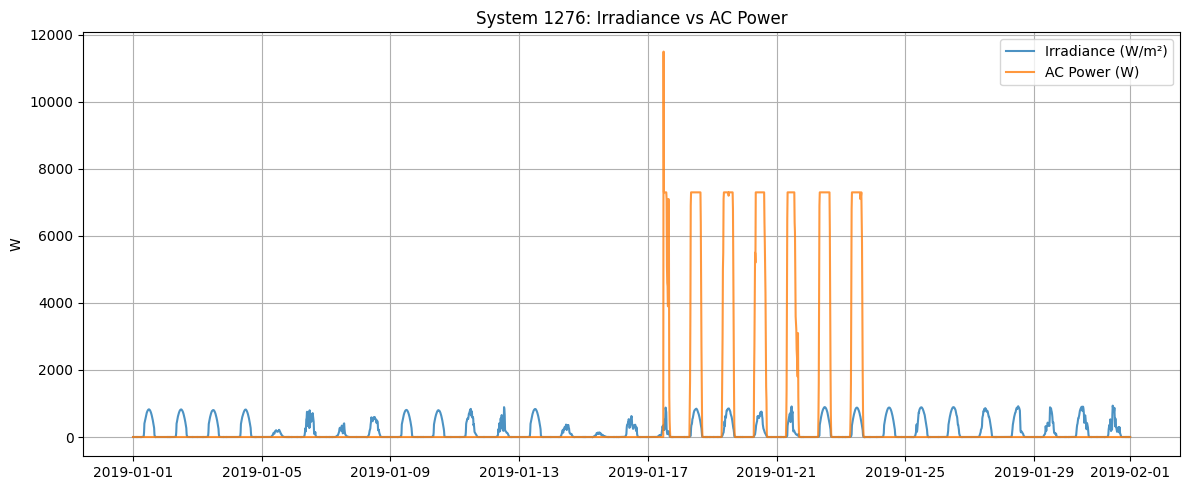

In [22]:
import matplotlib.pyplot as plt

def plot_power_vs_irradiance(df, title="Power vs Irradiance"):
    sample = df['2019-01-01':'2019-01-31']
    plt.figure(figsize=(12, 5))
    plt.plot(sample.index, sample['poa_irradiance'], label='Irradiance (W/m²)', alpha=0.8)
    plt.plot(sample.index, sample['ac_power_hw'], label='AC Power (W)', alpha=0.8)
    plt.legend()
    plt.title(title)
    plt.ylabel("W")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example
plot_power_vs_irradiance(sys1, title="System 1276: Irradiance vs AC Power")


#### Key observations:

- The irradiance pattern is consistent and follows a typical day-night solar cycle.
- However, AC power is mostly **zero**, except for a few sharp spikes around mid-January.
- This mismatch indicates a likely **inverter malfunction, disconnection, or operational downtime**.
- Despite sunlight being available, the system fails to deliver expected output.

---

####System 1277

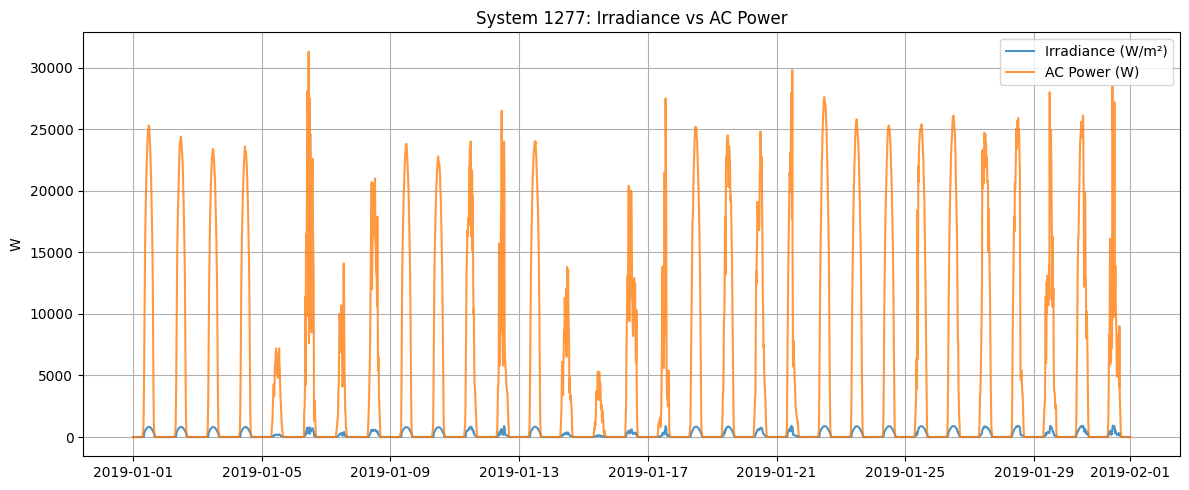

In [23]:
import matplotlib.pyplot as plt

def plot_power_vs_irradiance(df, title="Power vs Irradiance"):
    sample = df['2019-01-01':'2019-01-31']
    plt.figure(figsize=(12, 5))
    plt.plot(sample.index, sample['poa_irradiance'], label='Irradiance (W/m²)', alpha=0.8)
    plt.plot(sample.index, sample['ac_power_hw'], label='AC Power (W)', alpha=0.8)
    plt.legend()
    plt.title(title)
    plt.ylabel("W")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example
plot_power_vs_irradiance(sys2, title="System 1277: Irradiance vs AC Power")

#### Key observations:

- Shows a **healthy correlation** between irradiance and power output.
- AC power consistently tracks solar irradiance, peaking during the day and dropping at night.
- The system is likely **functioning properly**, with no major hardware or data anomalies.
- This serves as a **baseline reference for expected behavior**.

---

#### System 1278

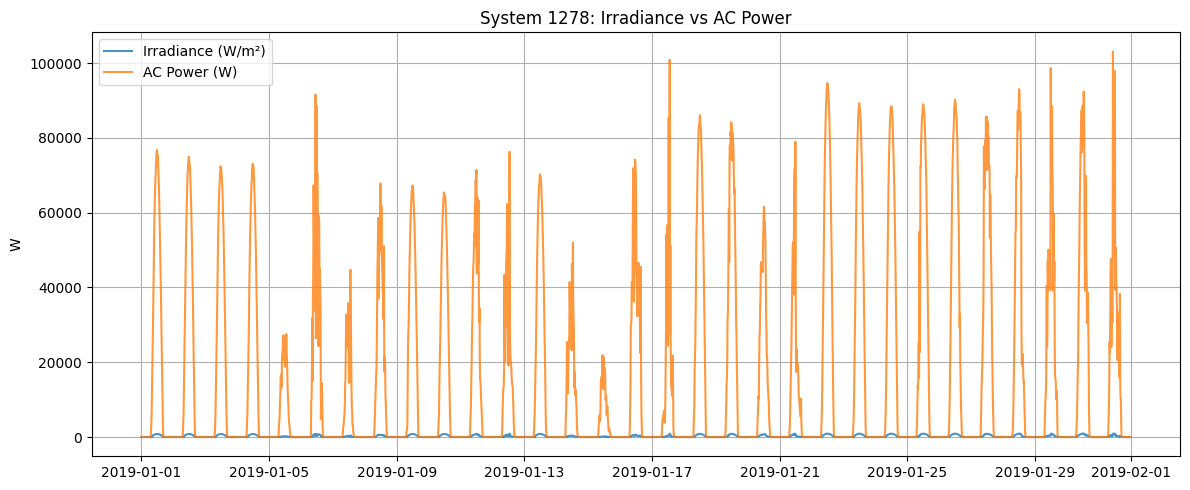

In [24]:
import matplotlib.pyplot as plt

def plot_power_vs_irradiance(df, title="Power vs Irradiance"):
    sample = df['2019-01-01':'2019-01-31']
    plt.figure(figsize=(12, 5))
    plt.plot(sample.index, sample['poa_irradiance'], label='Irradiance (W/m²)', alpha=0.8)
    plt.plot(sample.index, sample['ac_power_hw'], label='AC Power (W)', alpha=0.8)
    plt.legend()
    plt.title(title)
    plt.ylabel("W")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example
plot_power_vs_irradiance(sys3, title="System 1278: Irradiance vs AC Power")

#### Key observations:


- Produces the **highest power output**, as expected due to its larger system size.
- While irradiance patterns remain normal, the AC power shows **very high peaks** with some sharp drops.
- This may indicate **clipping, intermittent inverter faults, or control calibration issues**.
- Further diagnostics may be required to confirm long-term stability.

---

# Performance Ratio Over Time

#### System 1276:

The PR time series for System 1276 shows significant variability throughout the year, with several notable characteristics:

- Frequent high spikes (exceeding 150–200%) occur intermittently, especially during low-irradiance periods.
- Extended low-PR bands appear during mid-year months, suggesting potential seasonal losses.
- Sharp upward spikes near year-end indicate unstable expected energy estimates or sensor inconsistencies.



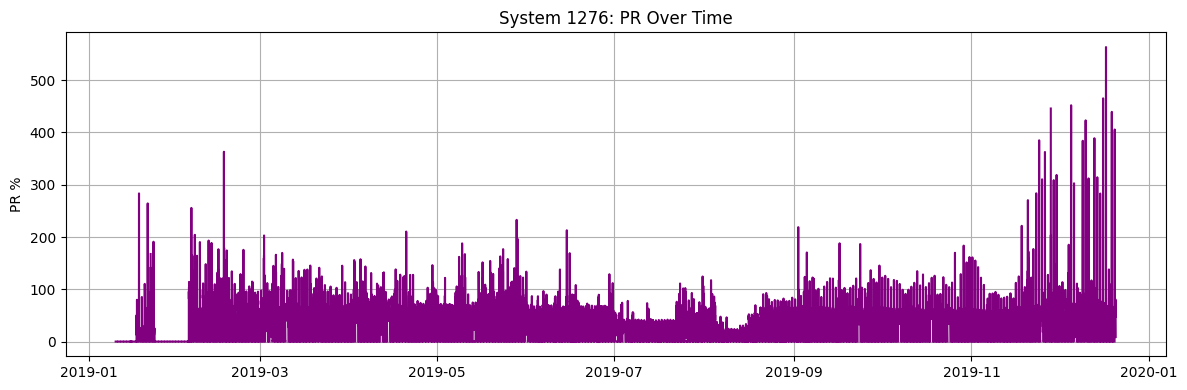

In [25]:
def plot_pr_trend(df, title="Performance Ratio (%)"):
    sample = df['2019-01-10':'2019-12-20']
    plt.figure(figsize=(12, 4))
    plt.plot(sample.index, sample['pr_percent'], label='PR (%)', color='purple')
    plt.title(title)
    plt.ylabel("PR %")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pr_trend(sys1, title="System 1276: PR Over Time")


**Interpretation:**
- High PR spikes during low irradiance are often caused by small denominators in expected energy, commonly due to irradiance sensor noise or near-zero irradiance conditions.
- The sustained lower PR during summer months may indicate temperature-related losses, mild soiling, or partial shading effects.
- Overall variability suggests that System 1276 is more sensitive to environmental and measurement inconsistencies compared to the other systems.

---

#### System 1277:

System 1277 exhibits comparatively more stable PR behavior:

- The majority of PR values cluster between 60% and 90%.
- Fewer extreme spikes are present, and when they occur, they are less persistent.
- Clear gaps in the time series correspond to known missing-data days identified earlier in preprocessing.



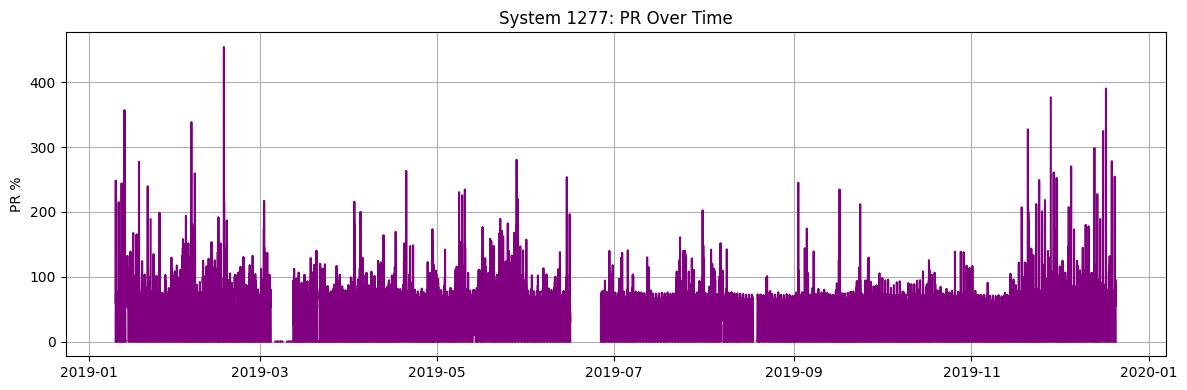

In [26]:
def plot_pr_trend(df, title="Performance Ratio (%)"):
    sample = df['2019-01-10':'2019-12-20']
    plt.figure(figsize=(12, 4))
    plt.plot(sample.index, sample['pr_percent'], label='PR (%)', color='purple')
    plt.title(title)
    plt.ylabel("PR %")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pr_trend(sys2, title="System 1277: PR Over Time")

**Interpretation:**
- The tighter PR distribution suggests more reliable sensor behavior and inverter response.
- Occasional elevated PR values still indicate dawn/dusk effects but are less severe than System 1276.
- Missing segments confirm that the PR analysis is consistent with earlier data availability checks.

---

#### System 1278:

System 1278, the largest system with a dual-inverter configuration, shows distinct behavior:

- PR remains relatively stable during most of the year, particularly during high-irradiance periods.
- Short bursts of elevated PR occur but are less frequent compared to smaller systems.
- Variability increases toward the end of the year.



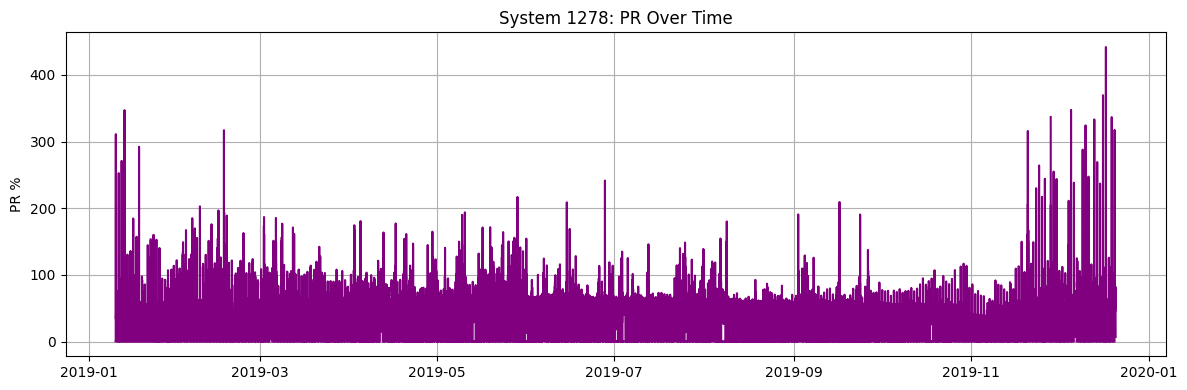

In [27]:
def plot_pr_trend(df, title="Performance Ratio (%)"):
    sample = df['2019-01-10':'2019-12-20']
    plt.figure(figsize=(12, 4))
    plt.plot(sample.index, sample['pr_percent'], label='PR (%)', color='purple')
    plt.title(title)
    plt.ylabel("PR %")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pr_trend(sys3, title="System 1278: PR Over Time")

**Interpretation:**
- The aggregation of two inverters smooths short-term fluctuations, leading to a more stable PR profile.
- Reduced sensitivity to noise indicates better redundancy and robustness in measurement.
- Late-year variability may point to seasonal effects or inverter-specific operational changes.

---

## Cross-System Comparison and Key Takeaways

Comparing PR trends across all three systems reveals several important insights:

- Larger systems (1278) exhibit smoother PR profiles due to aggregation effects.
- Smaller systems (1276) are more prone to volatility caused by sensor noise, partial shading, or low-irradiance conditions.
- System 1277 demonstrates the most balanced performance, making it a useful reference baseline.
- Extreme PR values are not always indicators of superior performance; instead, they often signal data or modeling limitations.

These observations justify the need for downstream diagnostic flagging, where PR anomalies are contextualized using irradiance levels, inverter signals, and cross-system comparisons rather than treated in isolation.


## Scatter: POA Irradiance vs AC Power

These scatter plots show the relationship between irradiance (W/m²) and AC power output (W) across all three systems. They serve as a diagnostic tool to evaluate the physical behavior and potential performance anomalies.


- **System 1276**:
  - Displays multiple bands or clusters of data, possibly indicating inverter clipping or inconsistent scaling behavior.
  - Some flat regions suggest constant power output irrespective of increasing irradiance, potentially pointing to a capacity limit or fault condition.


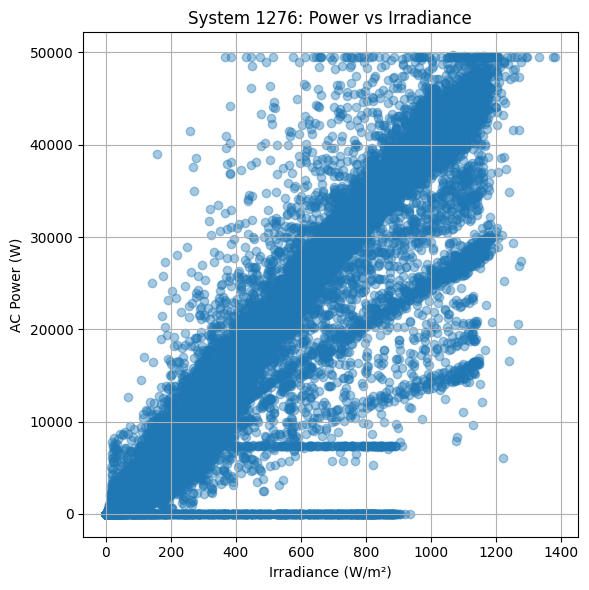

In [28]:
def plot_power_vs_irr_scatter(df, title="Power vs Irradiance Scatter"):
    plt.figure(figsize=(6, 6))
    plt.scatter(df['poa_irradiance'], df['ac_power_hw'], alpha=0.4)
    plt.xlabel("Irradiance (W/m²)")
    plt.ylabel("AC Power (W)")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_power_vs_irr_scatter(sys1, title="System 1276: Power vs Irradiance")

- **System 1277**:
  - Exhibits a much tighter and more linear relationship between irradiance and power.
  - A clear diagonal band implies healthy inverter performance with minimal clipping.

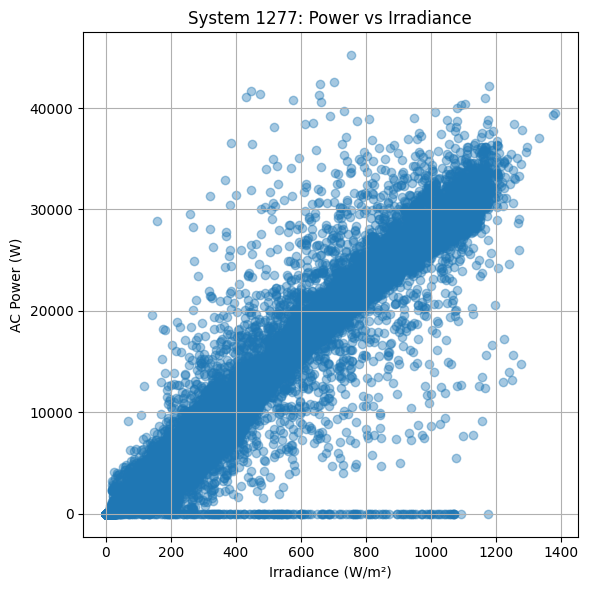

In [29]:
def plot_power_vs_irr_scatter(df, title="Power vs Irradiance Scatter"):
    plt.figure(figsize=(6, 6))
    plt.scatter(df['poa_irradiance'], df['ac_power_hw'], alpha=0.4)
    plt.xlabel("Irradiance (W/m²)")
    plt.ylabel("AC Power (W)")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_power_vs_irr_scatter(sys2, title="System 1277: Power vs Irradiance")

- **System 1278**:
  - Shows a strong linear trend with slightly more spread at higher irradiance levels.
  - Some deviation from linearity and broader dispersion may suggest intermittent anomalies or dual-inverter behavior, which aligns with known system design.


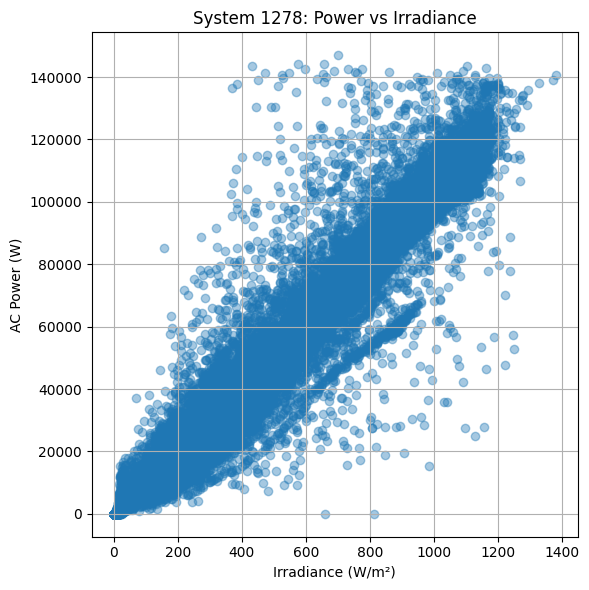

In [30]:
def plot_power_vs_irr_scatter(df, title="Power vs Irradiance Scatter"):
    plt.figure(figsize=(6, 6))
    plt.scatter(df['poa_irradiance'], df['ac_power_hw'], alpha=0.4)
    plt.xlabel("Irradiance (W/m²)")
    plt.ylabel("AC Power (W)")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_power_vs_irr_scatter(sys3, title="System 1278: Power vs Irradiance")

A strong linear correlation between irradiance and AC power is expected in well-performing systems. Deviations can indicate:
- Inverter clipping or curtailment
- Sensor calibration issues
- Soiling or partial shading events
- Temperature-induced efficiency losses

---

# Histogram: PR Distribution

**System 1276:**

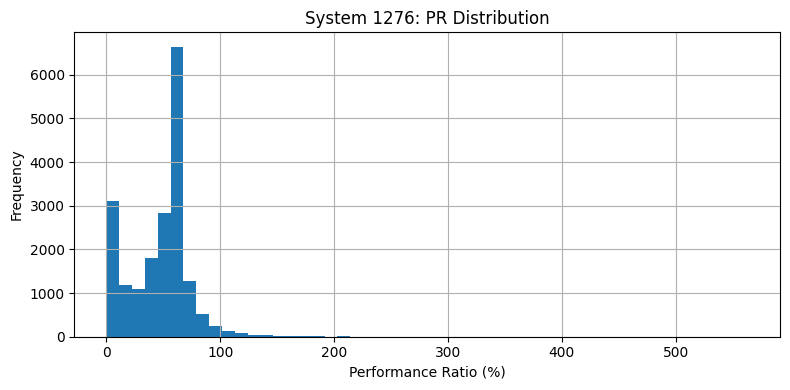

In [31]:
def plot_pr_distribution(df, title="PR Distribution"):
    plt.figure(figsize=(8, 4))
    df['pr_percent'].dropna().hist(bins=50)
    plt.title(title)
    plt.xlabel("Performance Ratio (%)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pr_distribution(sys1, title="System 1276: PR Distribution")



**Observations**:
- **System 1276** shows a positively skewed distribution with a high concentration of PR values between 60%–90%, indicating relatively stable performance. However, outliers above 200% may signal data quality or sensor faults.

---

 **System 1277:**


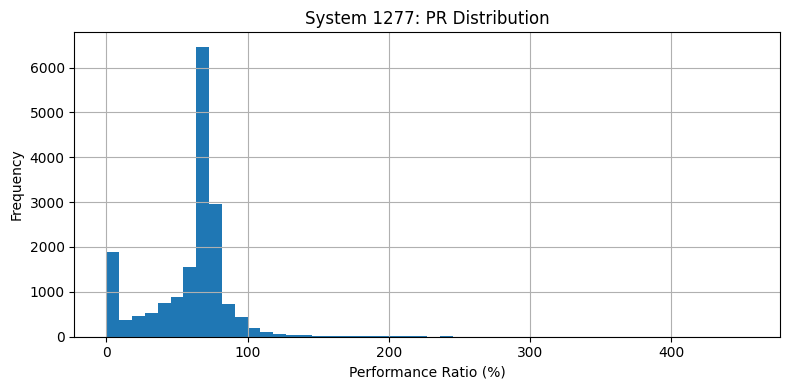

In [32]:
def plot_pr_distribution(df, title="PR Distribution"):
    plt.figure(figsize=(8, 4))
    df['pr_percent'].dropna().hist(bins=50)
    plt.title(title)
    plt.xlabel("Performance Ratio (%)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pr_distribution(sys2, title="System 1277: PR Distribution")


**Observations**:
- **System 1277** exhibits a narrower, slightly right-skewed distribution centered around 70–85%, suggesting consistent performance but also several readings exceeding 100%, warranting further validation.

---

**System 1278:**

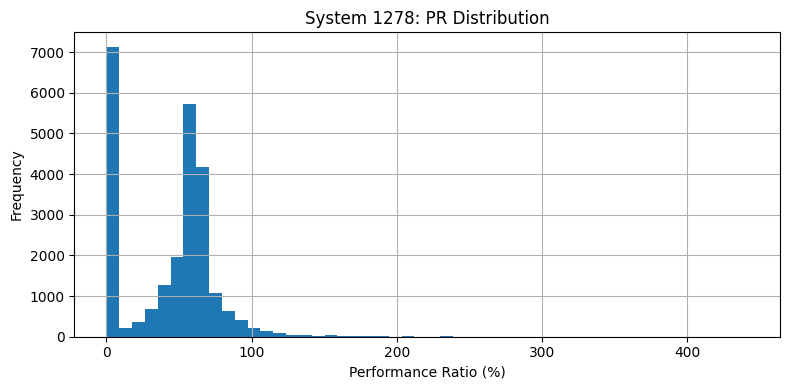

In [33]:
def plot_pr_distribution(df, title="PR Distribution"):
    plt.figure(figsize=(8, 4))
    df['pr_percent'].dropna().hist(bins=50)
    plt.title(title)
    plt.xlabel("Performance Ratio (%)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pr_distribution(sys3, title="System 1278: PR Distribution")


**Observations**:
- **System 1278** has a unique bimodal distribution with a notable cluster near 0%, indicating persistent zero output during sunlight hours — potentially pointing to string faults, inverter shutdowns, or snow cover. The second peak in the 70–85% range shows expected behavior during operational periods.

---

### Flagging

In this section, we implement a comprehensive set of flagging rules to detect operational anomalies and underperformance patterns across all three systems.

These flags allow us to isolate potential issues such as hardware faults, shading or soiling, sensor failures, and missing or anomalous data.


**Implemented Flags**:
- `flag_ac_zero_under_sun`: AC power is zero despite irradiance > 100 W/m². Often indicates inverter malfunction, disconnection, or DC-side faults.

In [34]:
def flag_zero_ac_power(df, irradiance_threshold=100):
    condition = (df['ac_power_hw'] <= 0) & (df['poa_irradiance'] > irradiance_threshold)
    df['flag_ac_zero_under_sun'] = condition
    return df


In [35]:
flag_zero_ac_power(sys1)
flag_zero_ac_power(sys2)

,system_id,system_size_kw,ac_power_hw,dc_power_hw,ac_current,ac_voltage,input_current,input_voltage,inverter_error_code,inverter_temp,...,power_factor,relative_humidity,wind_direction,wind_speed_mph,ambient_temp_f,interval_hours,actual_energy_wh,expected_energy_wh,pr_percent,flag_ac_zero_under_sun
measured_on,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,1277.0,40.56,0.0,-100.0,0.0,285.0,-1.0,0.0,0.0,11.0,...,0.0,29.669,351.607,2.768966,NaN,0.25,0.0,0.0,NaN,False
2019-01-01 00:15:00,1277.0,40.56,0.0,-100.0,0.0,285.0,-1.0,0.0,0.0,11.0,...,0.0,29.981,351.630,2.464084,NaN,0.25,0.0,0.0,NaN,False
2019-01-01 00:30:00,1277.0,40.56,0.0,-100.0,0.0,284.0,-1.0,0.0,0.0,11.0,...,0.0,30.700,351.630,2.472578,NaN,0.25,0.0,0.0,NaN,False
2019-01-01 00:45:00,1277.0,40.56,0.0,-100.0,0.0,284.0,-1.0,0.0,0.0,10.0,...,0.0,30.281,351.630,2.274092,NaN,0.25,0.0,0.0,NaN,False
2019-01-01 01:00:00,1277.0,40.56,0.0,-100.0,0.0,284.0,-1.0,0.0,0.0,10.0,...,0.0,29.969,351.630,2.738120,NaN,0.25,0.0,0.0,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 22:45:00,1277.0,40.56,0.0,-100.0,0.0,286.0,-1.0,0.0,0.0,16.0,...,0.0,49.925,351.585,0.000000,NaN,0.25,0.0,0.0,NaN,False
2019-12-31 23:00:00,1277.0,40.56,0.0,-100.0,0.0,286.0,-1.0,0.0,0.0,16.0,...,0.0,52.631,351.585,0.000000,NaN,0.25,0.0,0.0,NaN,False
2019-12-31 23:15:00,1277.0,40.56,0.0,-100.0,0.0,285.0,-1.0,0.0,0.0,16.0,...,0.0,55.069,351.585,0.000000,NaN,0.25,0.0,0.0,NaN,False


- `flag_low_pr_possible_shading_or_soiling`: PR drops below 60% during high irradiance (> 400 W/m²). Typically points to transient shading, dirty modules, or tracker misalignment.

In [36]:
def flag_low_pr_high_irradiance(df, irradiance_threshold=400, pr_threshold=60):
    condition = (df['poa_irradiance'] > irradiance_threshold) & (df['pr_percent'] < pr_threshold)
    df['flag_low_pr_possible_shading_or_soiling'] = condition
    return df


In [37]:
def compare_pr_between_systems(df_list):
    combined = pd.concat(df_list)
    combined = combined.reset_index()

    daily_avg_pr = combined.groupby(['measured_on', 'system_id'])['pr_percent'].mean().unstack()
    daily_avg_pr['diff_1276_1277'] = daily_avg_pr[1276] - daily_avg_pr[1277]
    daily_avg_pr['diff_1276_1278'] = daily_avg_pr[1276] - daily_avg_pr[1278]
    daily_avg_pr['diff_1277_1278'] = daily_avg_pr[1277] - daily_avg_pr[1278]

    return daily_avg_pr


- `flag_inverter_error`: Non-zero inverter error codes signal fault states.

In [38]:
def flag_inverter_issue(df):
    df['flag_inverter_error'] = (df['inverter_error_code'] != 0)
    df['flag_inverter_temp_high'] = (df['inverter_temp'] > 85)  # threshold can vary
    return df


- `flag_power_spike`: Sudden power fluctuations identified using a rolling standard deviation threshold.

In [39]:
def flag_power_spikes(df, window_size=20, threshold_std=3):
    df['ac_power_rolling_std'] = df['ac_power_hw'].rolling(window_size, min_periods=1).std()
    df['ac_power_spike'] = df['ac_power_rolling_std'] > df['ac_power_rolling_std'].mean() + threshold_std * df['ac_power_rolling_std'].std()
    return df


- `flag_missing_data`: Gaps in energy data (e.g., `actual_energy_wh` is missing).

In [40]:
def flag_missing_data(df):
    df['missing_interval'] = df['actual_energy_wh'].isna()
    return df


- `flag_poa_sensor_issue`: POA irradiance shows abnormally low variance, suggesting stuck or unresponsive sensors.


In [41]:
def flag_poa_sensor_stuck(df, window=10):
    df['irradiance_rolling_std'] = df['poa_irradiance'].rolling(window=window).std()
    df['flag_poa_sensor_issue'] = df['irradiance_rolling_std'] < 1  # very low variance
    return df


In [42]:
def plot_flags(df, system_id):
    flagged = df[(df['flag_low_pr_possible_shading_or_soiling']) |
                 (df['flag_ac_zero_under_sun']) |
                 (df['flag_inverter_error'])]

    plt.figure(figsize=(15, 5))
    plt.plot(df.index, df['pr_percent'], label='PR %', color='blue')
    plt.scatter(flagged.index, flagged['pr_percent'], color='red', label='Flagged Points')
    plt.title(f'System {system_id}: PR with Flagged Issues')
    plt.ylabel('PR %')
    plt.legend()
    plt.grid(True)
    plt.show()


- `flag_low_pr_vs_reference`: PR is >20% lower than a co-located reference system (System 1277). Flags system-specific issues in a comparative context.

In [ ]:
def flag_low_pr_vs_reference(df, reference_df, threshold=0.2):
    """
    Flags data points where PR is significantly lower than reference system's PR
    """
    df = df.copy()

    # Align both dataframes on datetime index
    pr_compare = pd.DataFrame({
        'pr': df['pr_percent'],
        'ref_pr': reference_df['pr_percent']
    }).dropna()

    # Flag where PR is significantly lower than reference system (e.g., >20% lower)
    df['flag_low_pr_vs_reference'] = pr_compare['pr'] < (1 - threshold) * pr_compare['ref_pr']

    # Fill NA (misaligned times) with False
    df['flag_low_pr_vs_reference'] = df['flag_low_pr_vs_reference'].fillna(False)

    return df

sys1 = flag_low_pr_vs_reference(sys1, reference_df=sys2)
sys2 = flag_low_pr_vs_reference(sys2, reference_df=sys2)
sys3 = flag_low_pr_vs_reference(sys3, reference_df=sys2)

In [44]:
def apply_all_flags(df):
    df = flag_zero_ac_power(df)
    df = flag_low_pr_high_irradiance(df)
    df = flag_inverter_issue(df)
    df = flag_power_spikes(df)
    df = flag_missing_data(df)
    df = flag_poa_sensor_stuck(df)
    return df


In [45]:
systems_data = {
    1276: sys1,
    1277: sys2,
    1278: sys3
}


In [46]:
flagged_systems = {
    system_id: apply_all_flags(df.copy())
    for system_id, df in systems_data.items()
}


**Relative Daily PR Comparison**:

By averaging daily PR values and comparing each system to the mean of the other two, we detect **System 1276 underperforming consistently** over many days — especially in early 2019. For instance:



In [47]:
def build_daily_pr_comparison(sys1, sys2, sys3):
    df = pd.concat([
        sys1[['pr_percent']].assign(system_id=1276),
        sys2[['pr_percent']].assign(system_id=1277),
        sys3[['pr_percent']].assign(system_id=1278)
    ])

    df = df.reset_index()
    daily_pr = (
        df
        .groupby([df['measured_on'].dt.date, 'system_id'])['pr_percent']
        .mean()
        .unstack()
    )

    return daily_pr

daily_pr = build_daily_pr_comparison(sys1, sys2, sys3)
daily_pr.head(50)


system_id,1276,1277,1278
measured_on,,,
2019-01-01,0.000000,63.296264,58.836824
2019-01-02,0.000000,62.590766,59.100736
2019-01-03,0.000000,61.118907,56.991979
2019-01-04,0.000000,59.710894,55.966148
2019-01-05,0.000000,64.191393,61.336569
2019-01-06,0.000000,74.070228,57.691008
2019-01-07,0.000000,59.854628,50.758166
2019-01-08,0.000000,67.045066,49.911904
2019-01-09,0.000000,55.241536,39.644612


- On multiple days (e.g., January 1–5, 2019), System 1276's PR is **significantly lower** (even zero), while the other two systems maintain stable PR around 60%.

This long-term underperformance strongly suggests **systemic issues** — such as a persistent inverter configuration problem, severe sensor errors, or a mismatch in metering setup — and warrants further investigation or corrective action.

## Relative Underperformance Detection (Peer Comparison)

In addition to absolute performance thresholds, we introduce a **relative underperformance flag** that compares each system against its peer systems operating at the **same site and under the same environmental conditions**.

This approach is powerful because it:
- Controls for weather variability (irradiance, temperature, clouds)
- Highlights **system-specific issues** rather than site-wide effects
- Mimics how operations teams compare assets in real-world monitoring

### Methodology

For each day:
- We compute the **daily average PR** for each system.
- A system is flagged as **underperforming** if its PR is significantly lower than the **average PR of the other two systems**.

The logic is:

$$
\text{System}_i \text{ underperforming if:}
$$

$$
PR_i < \left(\frac{PR_j + PR_k}{2}\right) - \text{threshold}
$$

Where:
- $PR_i$ is the daily PR of the system being evaluated
- $PR_j, PR_k$ are the PRs of the other two systems
- `threshold = 15` percentage points (configurable tolerance)

This creates three boolean flags:
- `1276_underperforming`
- `1277_underperforming`
- `1278_underperforming`

Each flag indicates **relative underperformance on that day**.


In [48]:
def flag_relative_underperformance(daily_pr, threshold=15):
    flags = pd.DataFrame(index=daily_pr.index)

    flags['1276_underperforming'] = (
        daily_pr[1276] < daily_pr[[1277, 1278]].mean(axis=1) - threshold
    )

    flags['1277_underperforming'] = (
        daily_pr[1277] < daily_pr[[1276, 1278]].mean(axis=1) - threshold
    )

    flags['1278_underperforming'] = (
        daily_pr[1278] < daily_pr[[1276, 1277]].mean(axis=1) - threshold
    )

    return flags


In [49]:

relative_flags = flag_relative_underperformance(daily_pr)
relative_flags.head(50)

,1276_underperforming,1277_underperforming,1278_underperforming
measured_on,,,
2019-01-01,True,False,False
2019-01-02,True,False,False
2019-01-03,True,False,False
2019-01-04,True,False,False
2019-01-05,True,False,False
2019-01-06,True,False,False
2019-01-07,True,False,False
2019-01-08,True,False,False
2019-01-09,True,False,False



From the sample output:

- **System 1276 is consistently flagged as underperforming** across many consecutive days (January 2019).
- **Systems 1277 and 1278 are rarely flagged**, indicating they behave as strong reference systems during this period.

This tells us:
- The low PR observed in System 1276 is **not driven by site-wide conditions** (irradiance, weather).
- Instead, it is **system-specific**, reinforcing earlier flags such as:
  - Zero AC output under sun
  - Persistent low PR under high irradiance
  - Sensor or inverter-related anomalies

Notably:
- Periods where `1276_underperforming = False` align with dates where PRs converge, suggesting **temporary recovery or normalization**.
- The appearance of `1278_underperforming = True` on later dates (e.g., Feb 19) suggests **episodic degradation**, not chronic failure.

---

### Interpretation of Flag Summary Table

The **flag summary table** consolidates the number of issues detected across each system using a range of rule-based diagnostics. This table is a **critical snapshot of system health**, allowing us to:

- Quantify which systems are underperforming or experiencing frequent issues.
- Diagnose the **root causes** — whether environmental (shading, soiling), mechanical (inverter failure), or sensor-related (POA sensor stuck).
- Prioritize field technician efforts by identifying systems with persistent or critical issues.


In [50]:
# Apply all flags and store updated dataframes
# Create a summary DataFrame
flag_summary = {}
for system_id, df in flagged_systems.items():
    summary = {
        'zero_ac_under_sun': df['flag_ac_zero_under_sun'].sum(),
        'low_pr_possible_shading_or_soiling': df['flag_low_pr_possible_shading_or_soiling'].sum(),
        'low_pr_vs_reference': df['flag_low_pr_vs_reference'].sum() if 'flag_low_pr_vs_reference' in df.columns else 0,
        'inverter_error': df['flag_inverter_error'].sum(),
        'inverter_temp_high': df['flag_inverter_temp_high'].sum(),
        'ac_power_spike': df['ac_power_spike'].sum(),
        'missing_interval': df['missing_interval'].sum(),
        'poa_sensor_issue': df['flag_poa_sensor_issue'].sum(),
    }
    flag_summary[system_id] = summary

flag_summary_df = pd.DataFrame(flag_summary).T
flag_summary_df



,zero_ac_under_sun,low_pr_possible_shading_or_soiling,low_pr_vs_reference,inverter_error,inverter_temp_high,ac_power_spike,missing_interval,poa_sensor_issue
1276,813,6666,4194,9,0,0,6,7100
1277,220,905,0,1279,0,2,1278,7031
1278,2,5220,2971,1088,0,0,4,7100


#### Key Takeaways:

- **System 1276** stands out with:
  - **Very high POA sensor anomalies (7100)**, suggesting the irradiance sensor is often stuck or unresponsive, potentially distorting PR calculation.
  - **6666 low PR values during high irradiance**, pointing toward performance issues unrelated to weather, possibly due to partial outages or degradation.
  - **813 instances of zero AC output despite sun**, a strong indicator of inverter disconnection or downstream faults.
  - **4194 low PR vs. reference flags**, meaning it significantly underperformed relative to System 1277 on many days.

  ⟶ _Together, this points to **persistent underperformance** likely driven by faulty sensors and deeper hardware issues. This system requires thorough inspection, especially of the sensors and inverter setup._

- **System 1277** shows a different profile:
  - **1279 inverter error codes** suggest multiple inverter-level hardware faults or configuration problems.
  - **1278 missing energy intervals**, implying frequent logging failures or meter issues.
  - In contrast, it has **relatively few low PR or zero-output anomalies**, meaning generation quality is better when data is valid.

  ⟶ _These flags suggest **intermittent faults** rather than chronic underperformance. Investigating data logging, inverter firmware, or communication faults is the next step._

- **System 1278** appears more stable in terms of AC output:
  - **Only 2 zero-output-under-sun events**, indicating robust inverter operation.
  - However, **5220 instances of low PR under high irradiance** highlight possible **shading or soiling patterns** (e.g., partial dirt coverage or obstruction).
  - **2971 low PR vs. reference days**, especially when System 1277 performs well, suggest this system is lagging more often.

  ⟶ _While no major hardware fault is apparent, this system likely suffers from **environmental degradation** or early-stage component wear. Cleaning, IV curve testing, or thermal inspections may help validate the root cause._

---
This breakdown helps stakeholders:
- Identify **performance trends** across co-located systems.
- Schedule **data-informed maintenance**  i.e., send technicians to the right site with the right focus.
- Ensure long-term **energy yield and contract compliance** by addressing recurring issues proactively.

Ultimately, this kind of anomaly detection ensures **operational transparency**, reduces downtime, and supports **financial guarantees** (e.g., PR warranties or uptime SLAs).

---

#   Systems Flag and Performance Analysis



###  Daily Flag Summary (January 2019):
The stacked area plots below display the **daily count of performance flags** for each of the three systems (1276, 1277, 1278) over the month of **January 2019**. Each flag represents a potential operational issue or anomaly identified by our automated flagging functions. Here's what we observe and interpret from these charts:


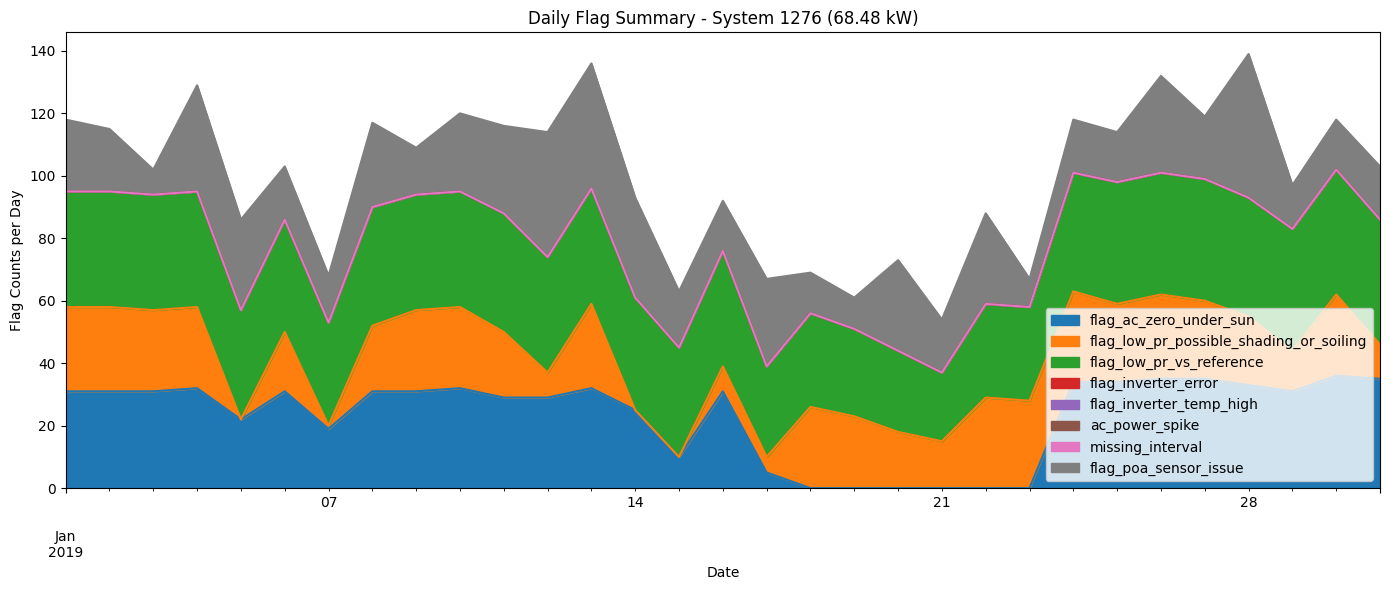

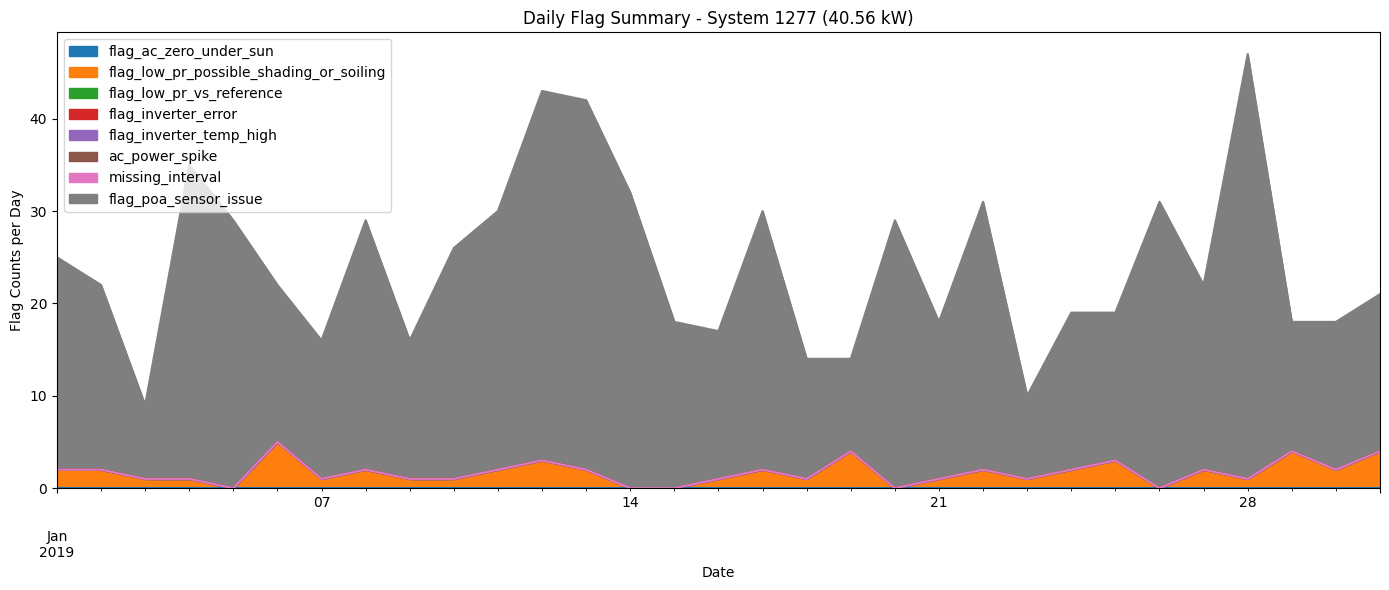

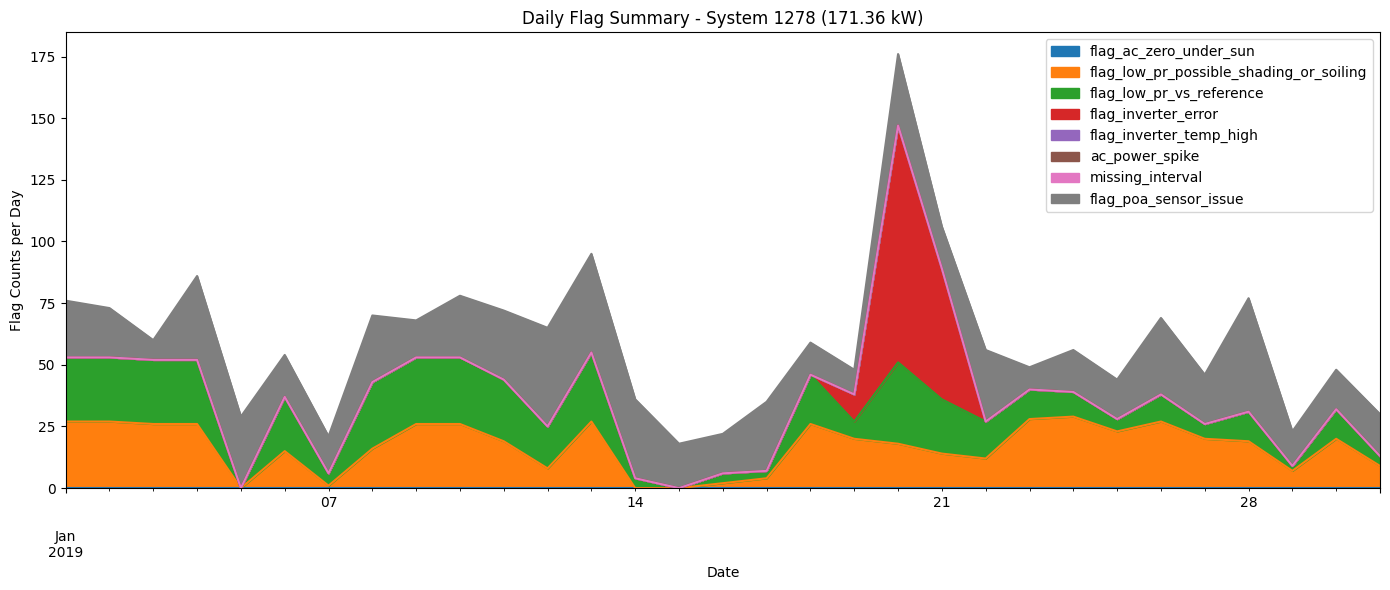

In [51]:
# 1. Add system sizes
system_sizes_kw = {
    1276: 68.48,
    1277: 40.56,
    1278: 171.36
}

# 2. Create daily summary DataFrame
daily_summaries = []

for system_id, df in flagged_systems.items():
    df = df.copy()
    df['date'] = df.index.date

    summary = df.groupby('date').agg({
        'pr_percent': 'mean',
        'poa_irradiance': 'mean',
        'flag_ac_zero_under_sun': 'sum',
        'flag_low_pr_possible_shading_or_soiling': 'sum',
        'flag_low_pr_vs_reference': 'sum',
        'flag_inverter_error': 'sum',
        'flag_inverter_temp_high': 'sum',
        'ac_power_spike': 'sum',
        'missing_interval': 'sum',
        'flag_poa_sensor_issue': 'sum'
    }).rename(columns={
        'pr_percent': 'avg_pr_percent',
        'poa_irradiance': 'avg_poa_irradiance',
    })
    summary['system_id'] = system_id
    daily_summaries.append(summary)

daily_summary_df = pd.concat(daily_summaries).reset_index()
daily_summary_df['system_id'] = daily_summary_df['system_id'].astype(int)
daily_summary_df['date'] = pd.to_datetime(daily_summary_df['date'])

# 3. Plot 1: Daily Flag Summary (stacked area)
flag_columns = [
    'flag_ac_zero_under_sun',
    'flag_low_pr_possible_shading_or_soiling',
    'flag_low_pr_vs_reference',
    'flag_inverter_error',
    'flag_inverter_temp_high',
    'ac_power_spike',
    'missing_interval',
    'flag_poa_sensor_issue'
]

plot_df = daily_summary_df[daily_summary_df['date'].between('2019-01-01', '2019-01-31')]

for system_id in plot_df['system_id'].unique():
    sys_df = plot_df[plot_df['system_id'] == system_id].set_index('date')
    sys_df[flag_columns].plot.area(stacked=True, figsize=(14, 6),
                                   title=f"Daily Flag Summary - System {system_id} ({system_sizes_kw[system_id]} kW)")
    plt.ylabel("Flag Counts per Day")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()





#### System 1276 (68.48 kW)
- **High flag activity** throughout the month; especially:
  - `flag_low_pr_vs_reference` and `flag_ac_zero_under_sun` dominate.
  - Notable days: Jan 5–6 and Jan 13 show total flags exceeding 130.
  - Consistent occurrence of `flag_poa_sensor_issue`, indicating possible irradiance sensor reliability issues.
  - Multiple types of flags appearing concurrently — pointing to multi-causal underperformance.

#### System 1277 (40.56 kW)
- **Significantly fewer flags overall**.
  - Almost entirely dominated by `flag_poa_sensor_issue`, suggesting a potential sensor hardware issue or data pipeline error.
  - Very few performance-related flags (`flag_low_pr` or `ac_zero_under_sun`), suggesting the system may be operating consistently but with poor sensor feedback.

#### System 1278 (171.36 kW)
- Several days of **high flag activity**, most notably:
  - Jan 20–21: Massive spike in `flag_inverter_error`, indicating likely inverter failure or disconnect.
  - `flag_low_pr_vs_reference` and `shading_or_soiling` flags occur regularly.
  - This system has the largest capacity and shows compound failure signals — making it the highest priority for maintenance intervention.

---

###  Daily Average PR vs POA Irradiance (2019):

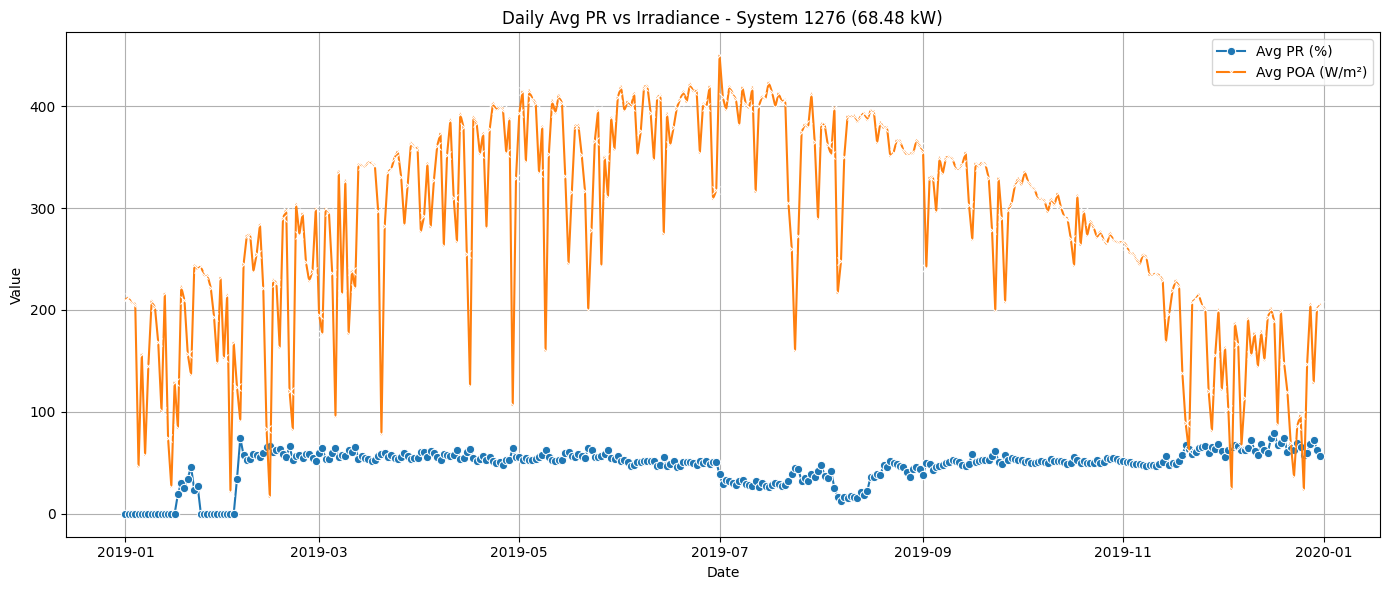

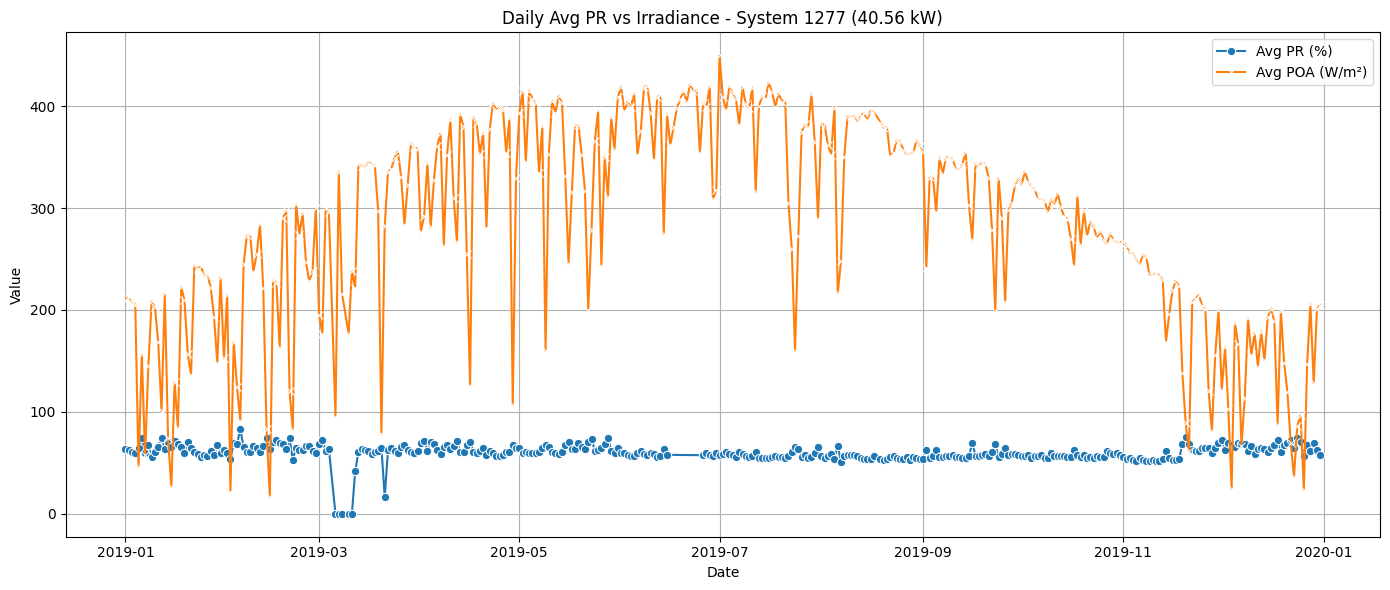

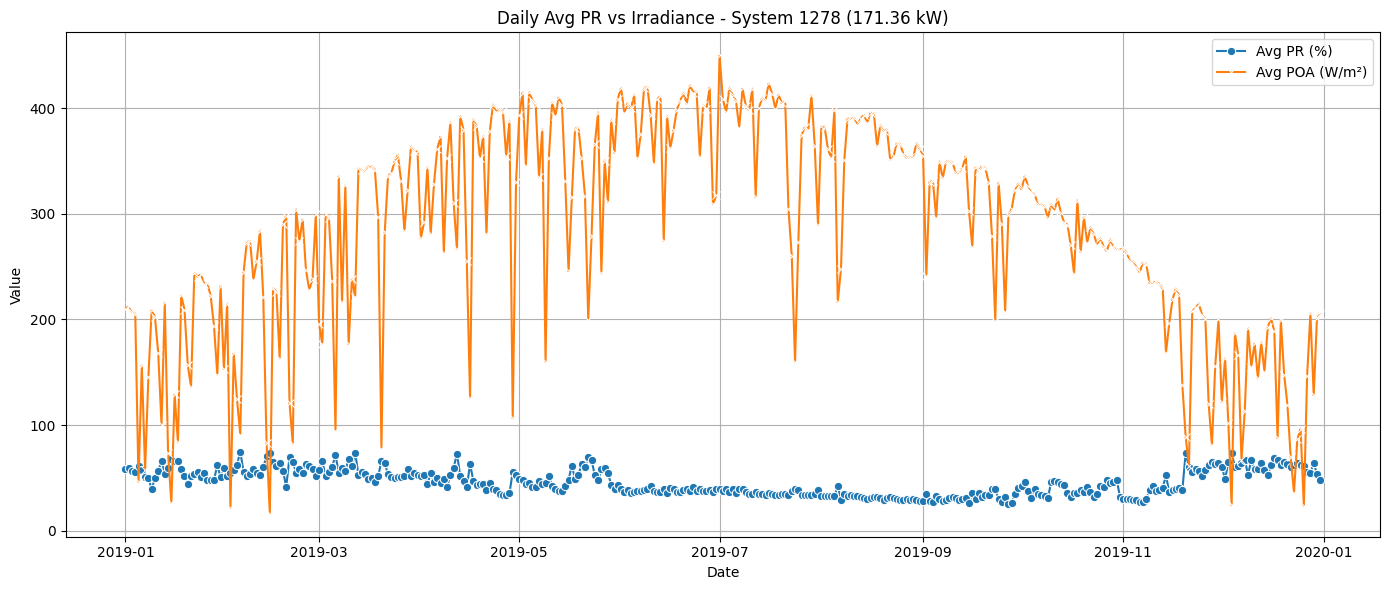

In [52]:
# 4. Plot 2: PR vs POA Irradiance (line)
for system_id, df in flagged_systems.items():
    df = df.copy()
    df['date'] = df.index.date

    daily_avg = df.groupby('date')[['pr_percent', 'poa_irradiance']].mean().reset_index()

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=daily_avg, x='date', y='pr_percent', label='Avg PR (%)', marker='o')
    sns.lineplot(data=daily_avg, x='date', y='poa_irradiance', label='Avg POA (W/m²)', marker='x')

    plt.title(f"Daily Avg PR vs Irradiance - System {system_id} ({system_sizes_kw[system_id]} kW)")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### System 1276
- **Avg PR (%)** remains mostly stable (around 50–65%), with small dips mid-year and late fall.
- POA irradiance shows clear seasonality with expected summer peaks and winter lows.
- Some visible days where POA is high but PR drops — potential shading or inverter inefficiency.

#### System 1277
- **PR is more stable**, hovering ~60–70%, showing less fluctuation despite seasonal irradiance change.
- Indicates good consistency in performance — despite the high count of POA sensor issues seen earlier.
- Low irradiance and low PR alignment confirms system behavior follows weather-driven irradiance.

#### System 1278
- **Widest PR fluctuations** (ranging from 25–75%) and irregularities throughout the year.
- Significant PR dips in July and September not aligned with irradiance dips — likely due to inverter or system faults.
- Very high irradiance levels during summer with lower-than-expected PR confirms efficiency loss or hardware underperformance.

---


### Daily PR Comparison Across Systems:

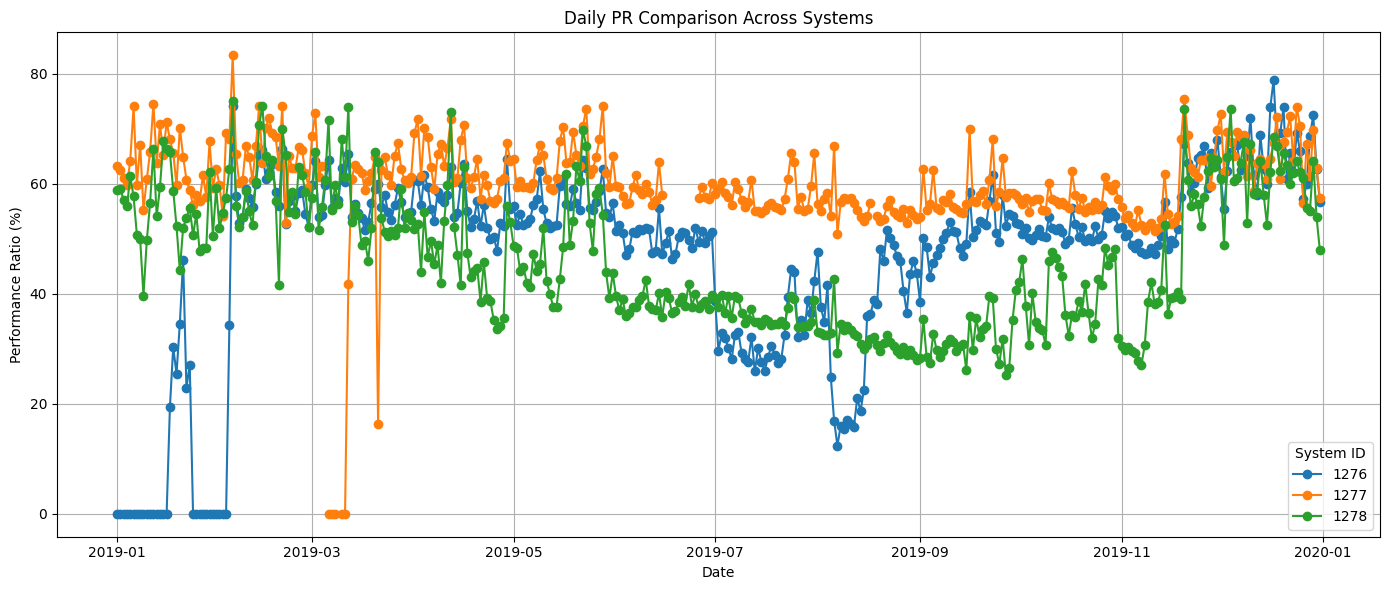

In [53]:
# 5. Plot 3: PR Comparison Across Systems
daily_pr_compare = []

for system_id, df in flagged_systems.items():
    df = df.copy()
    df['date'] = df.index.date
    daily_pr = df.groupby('date')['pr_percent'].mean().reset_index()
    daily_pr['system_id'] = system_id
    daily_pr_compare.append(daily_pr)

daily_pr_compare_df = pd.concat(daily_pr_compare)
pivoted = daily_pr_compare_df.pivot(index='date', columns='system_id', values='pr_percent')

pivoted.plot(marker='o', figsize=(14, 6))
plt.title("Daily PR Comparison Across Systems")
plt.xlabel("Date")
plt.ylabel("Performance Ratio (%)")
plt.grid(True)
plt.legend(title="System ID")
plt.tight_layout()
plt.show()



- **System 1277** consistently outperforms both 1276 and 1278, with fewer fluctuations and highest daily PR medians.
- **System 1278** shows frequent dips — reflecting the flag spike seen around Jan 20 and lower average performance.
- **System 1276** has a middle ground but shows notable PR deterioration mid-year (June to September).
- All systems show seasonal trends consistent with irradiance patterns, but System 1278 stands out for inconsistent performance unrelated to weather — requiring further diagnostics.

---

## Calendar Heatmap: Temporal Distribution of Performance Issues

To better understand *when* performance issues occur, we visualize selected flags using **calendar-style heatmaps**. Each heatmap aggregates daily flag counts by **weekday (rows)** and **week-of-month (columns)**, allowing us to identify recurring temporal patterns that may not be obvious in time‑series plots.

### What This Visualization Shows
- **Color intensity** represents the total count of selected flags on a given day.
- **Rows (Weekdays)** help identify weekday vs weekend behavior.
- **Columns (Week of Month)** highlight whether issues cluster in specific weeks.
- Each heatmap is generated **per system and per month**, enabling side‑by‑side comparison across systems and time.

For this analysis, we visualize **six months (January–June 2019)** for all three systems.

---

## Selected Flag for This Analysis

```python
selected_flags = [
    'flag_low_pr_possible_shading_or_soiling'
]
```
At this stage, we focus on low PR under high irradiance, which is a strong indicator of:

- Soiling (dust, dirt accumulation)

- Partial shading

- Degradation or mismatch effects not explained by weather alone

The framework is intentionally flexible. By editing the selected_flags list, the same calendar visualization can be reused to analyze:

- Inverter errors

- POA sensor issues

- AC power = 0 under sun

- Missing data intervals

- Power spikes


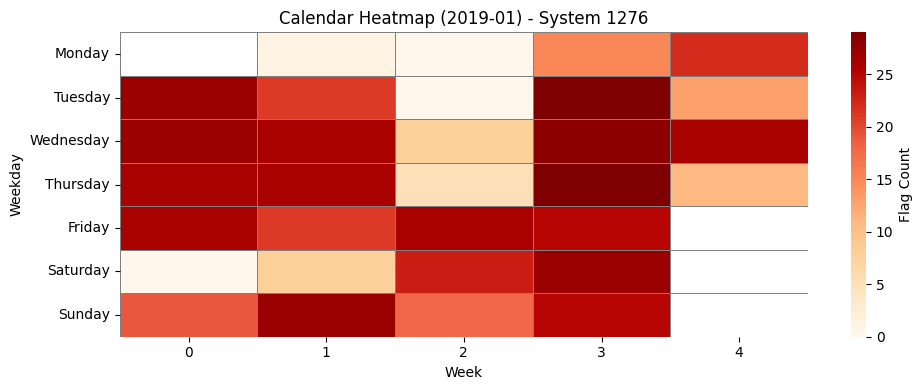

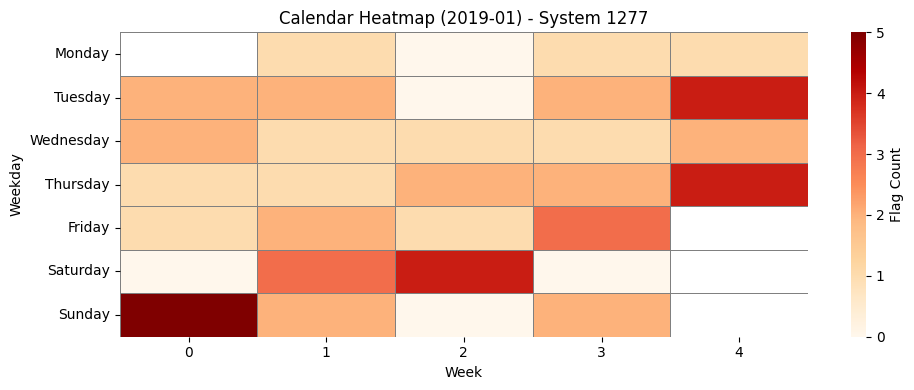

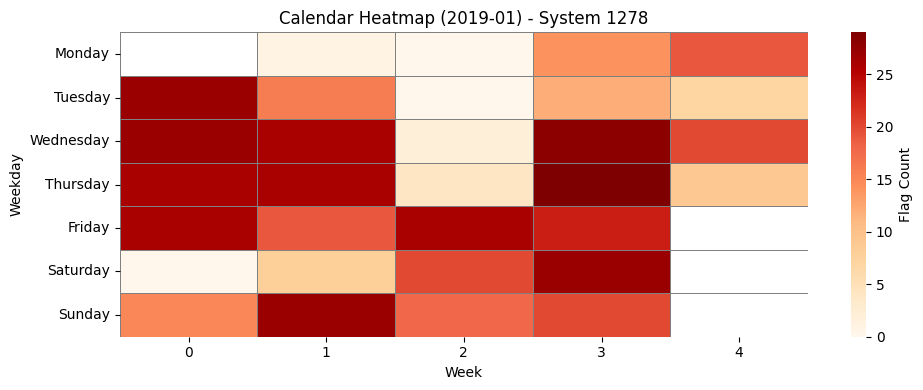

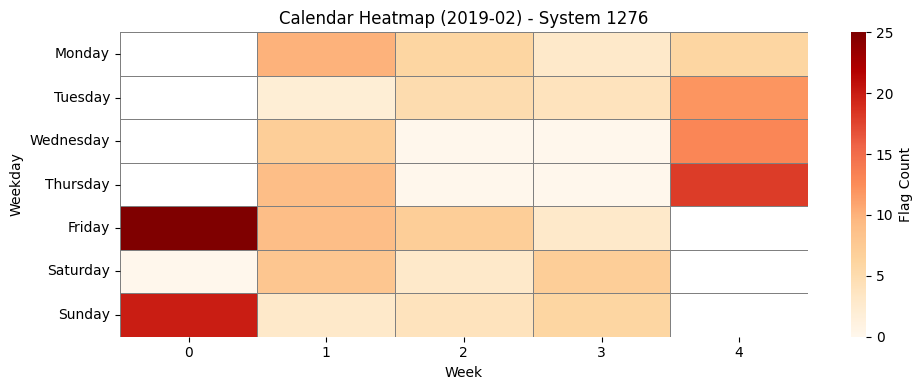

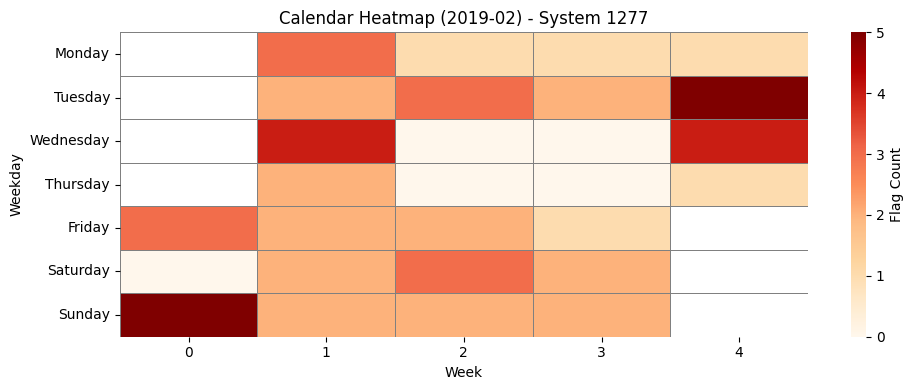

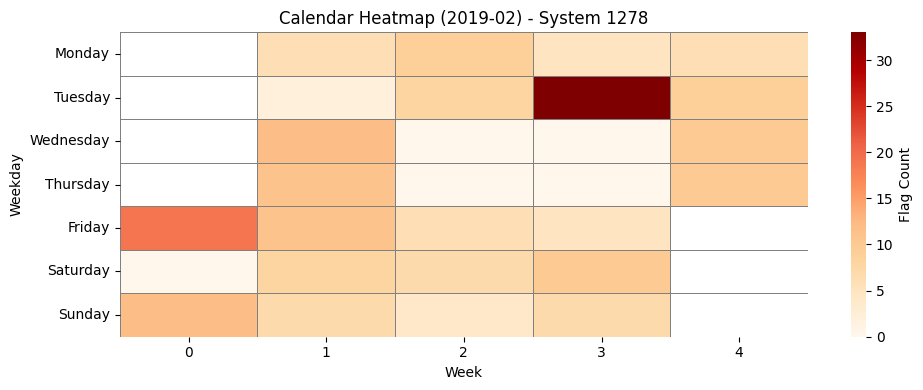

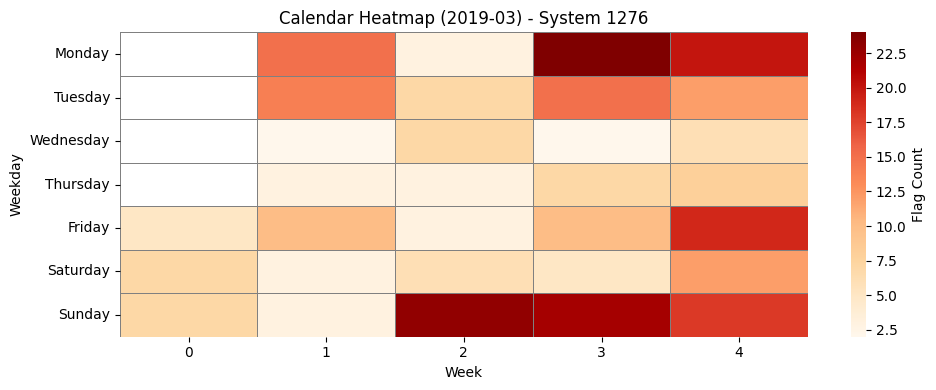

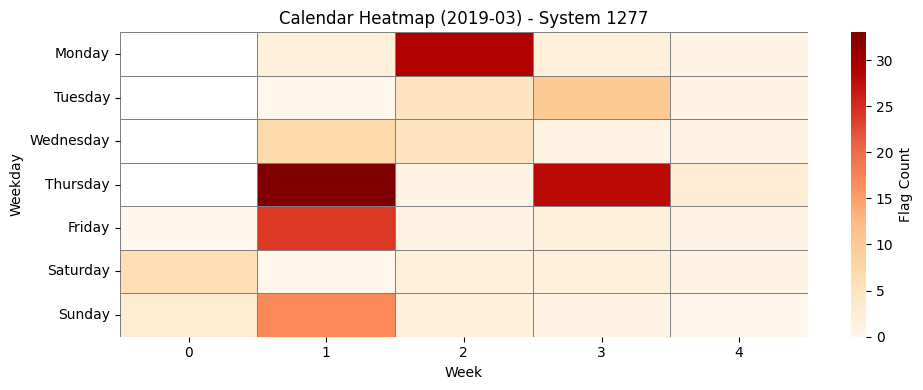

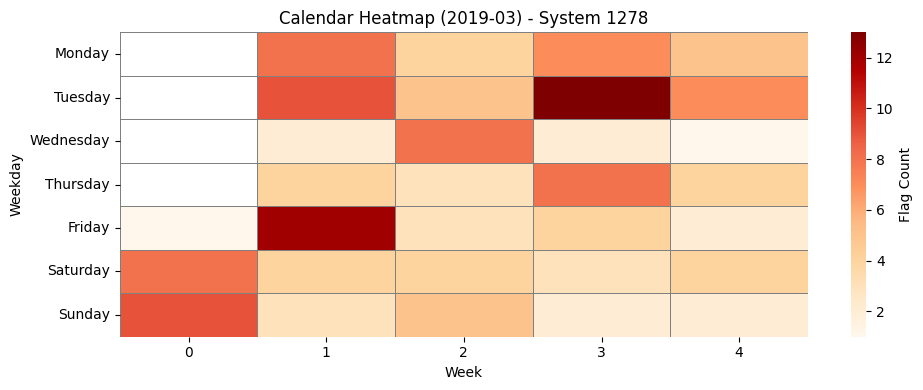

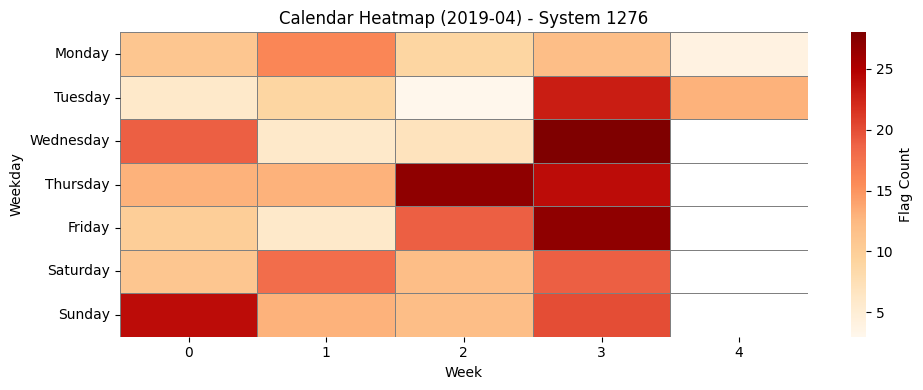

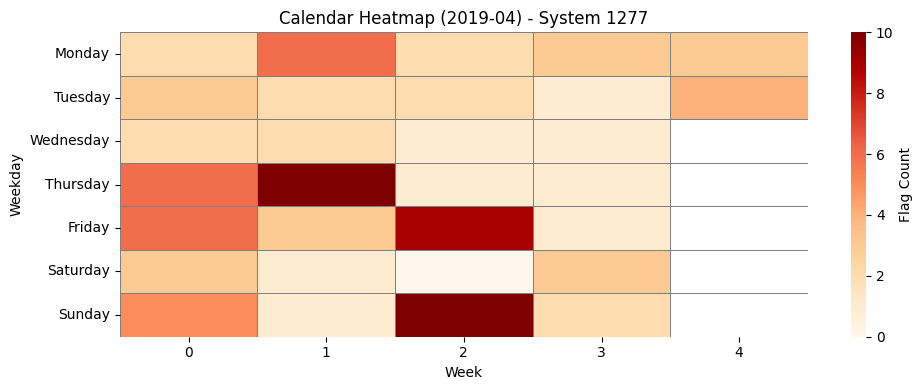

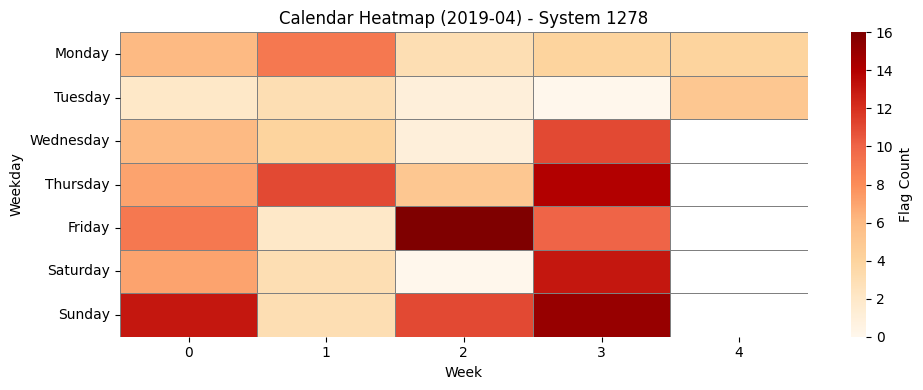

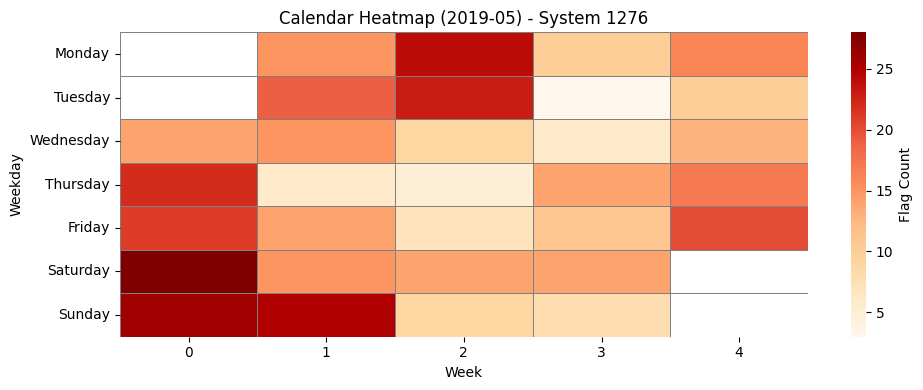

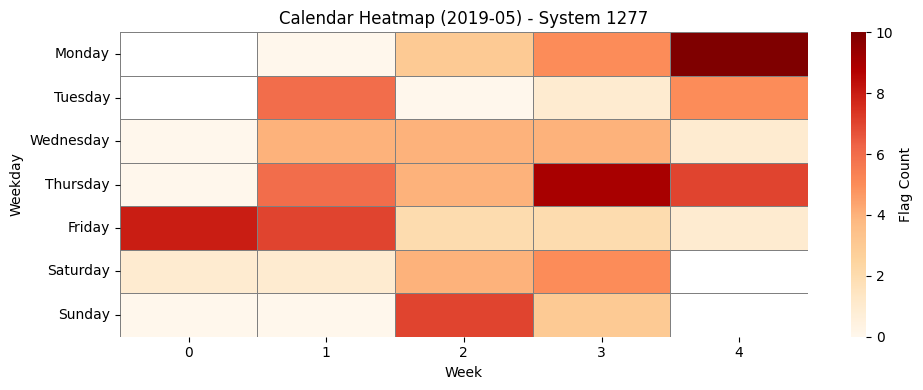

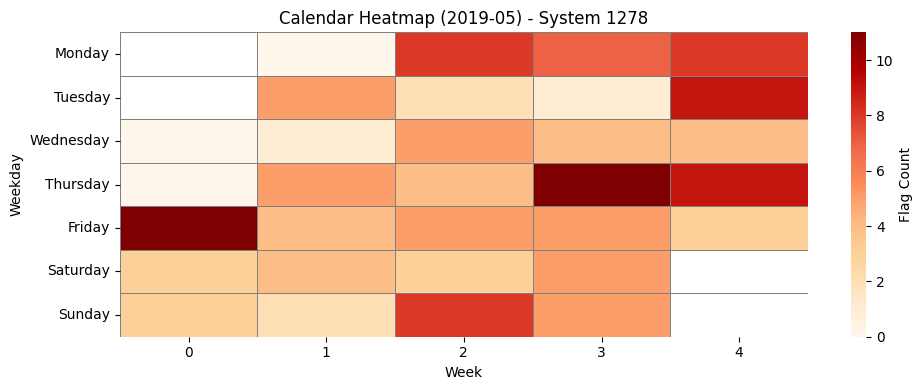

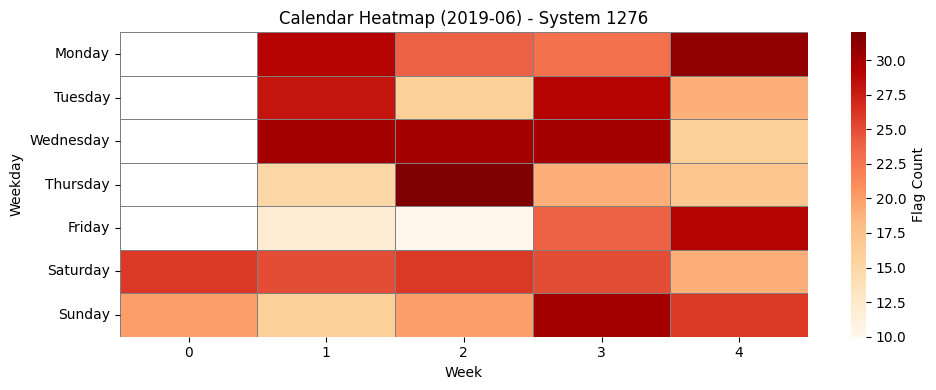

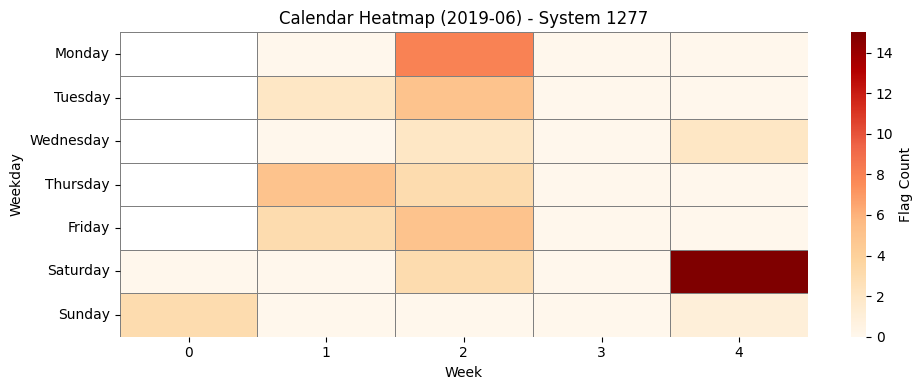

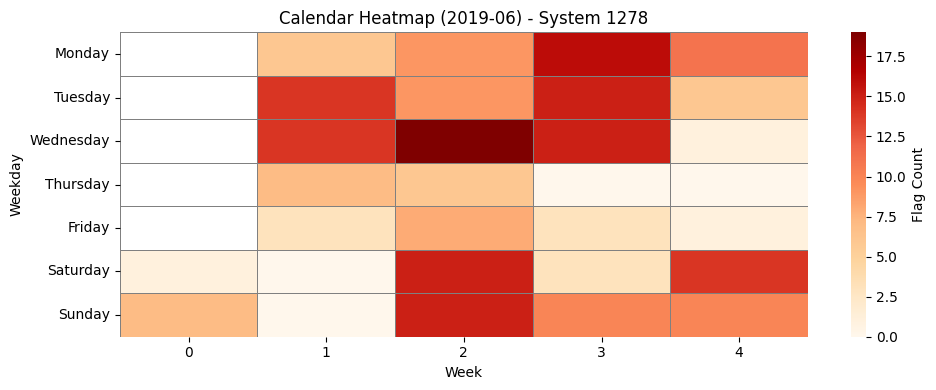

In [54]:


# Choose flags to visualize (edit this list as needed)
selected_flags = [
    'flag_low_pr_possible_shading_or_soiling',  # shading or soiling
    # 'flag_low_pr_vs_reference',              # if available
    # 'flag_inverter_error',                   # inverter issues
    # 'flag_poa_sensor_issue',                 # sensor
    # 'flag_ac_zero_under_sun',
    # 'missing_interval',
    # 'ac_power_spike',
]

def plot_flag_calendar(df, system_id, month_str, selected_flags):
    """Plot heatmap calendar for a single system and month"""
    df_month = df[
        (df['system_id'] == system_id) &
        (df['date'].dt.to_period('M') == pd.Period(month_str))
    ].copy()

    if df_month.empty:
        return  # skip empty months

    # Sum only selected flags
    df_month['total_flags'] = df_month[selected_flags].sum(axis=1)
    df_month['day'] = df_month['date'].dt.day
    df_month['weekday'] = df_month['date'].dt.weekday
    df_month['week'] = df_month['date'].dt.isocalendar().week
    df_month['week_rel'] = df_month['week'] - df_month['week'].min()

    calendar_grid = df_month.pivot(index='weekday', columns='week_rel', values='total_flags')

    # Plot
    plt.figure(figsize=(10, 4))
    sns.heatmap(
        calendar_grid,
        cmap='OrRd',
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': 'Flag Count'}
    )
    plt.title(f'Calendar Heatmap ({month_str}) - System {system_id}')
    plt.ylabel('Weekday')
    plt.xlabel('Week')
    plt.yticks(ticks=np.arange(7)+0.5, labels=calendar.day_name[:7], rotation=0)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Loop through Jan to Jun and all 3 systems
months = ['2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06']

for month_str in months:
    for system_id in daily_summary_df['system_id'].unique():
        plot_flag_calendar(daily_summary_df, system_id, month_str, selected_flags)


#### Key Observations from the Calendar Heatmaps
1. **Repeating Weekday Patterns**

   Across multiple months, certain weekdays consistently show higher flag densities. This suggests that the observed issues are systematic rather than random, potentially linked to:

   - Site operations or cleaning schedules

   - Human activity near the array

   - Persistent shading objects (e.g., nearby structures, trees)

2. **Week-to-Week Clustering**

   Some weeks show concentrated periods of elevated flags rather than isolated days. This behavior is typical of:

   - Gradual soiling accumulation before maintenance

   - Temporary environmental factors (e.g., construction, nearby obstructions)

   - Seasonal effects impacting sun angle and shading geometry

3. **Cross-System Consistency**

   Because all three systems are co-located, similar calendar patterns across systems suggest site-level drivers (weather, environment).
   In contrast, deviations in a single system point toward system-specific issues, such as:

   - String-level shading

   - Inverter configuration differences

   - Hardware degradation

4. **Seasonal Progression**

   From January through June, the heatmaps show evolving patterns consistent with:

   - Increasing irradiance and longer days

   - Changing sun angles affecting shading behavior

   - Accumulation and partial mitigation of soiling

This confirms that the flagging logic is sensitive to real physical drivers, not just noise.

---

## Automated Monthly Insights by System

To supplement the visual heatmaps, I’ve created a **text-based insight engine** that summarizes key diagnostic flags **month-by-month** for each system.

This is helpful for:
- Quickly reviewing performance anomalies without diving into raw plots
- Highlighting **system-specific vs. site-wide issues**
- Flagging months that need technician investigation

---



In [55]:
from collections import defaultdict

def generate_insights(df, system_id):
    """Generate textual insights for a given system's daily data"""
    insights = []

    # Filter by system
    sys_df = df[df['system_id'] == system_id].copy()
    sys_df['month'] = sys_df['date'].dt.to_period('M')

    grouped = sys_df.groupby('month')

    for month, group in grouped:
        msg_prefix = f"{month.strftime('%B %Y')}:"
        count_flags = lambda col, thresh: group[col].sum() >= thresh

        # Example thresholds (adjust if needed)
        if count_flags('flag_low_pr_possible_shading_or_soiling', 5):
            insights.append(f"{msg_prefix} possible shading or soiling detected (low PR with sun).")

        if count_flags('flag_inverter_error', 5):
            insights.append(f"{msg_prefix} repeated inverter faults observed.")

        if count_flags('flag_poa_sensor_issue', 5):
            insights.append(f"{msg_prefix} irregular POA readings → possible sensor issue.")

        if count_flags('flag_ac_zero_under_sun', 5):
            insights.append(f"{msg_prefix} AC power zero during irradiance → possible disconnection.")

        if group['avg_pr_percent'].mean() < 60:
            insights.append(f"{msg_prefix} overall PR was below 60% — check performance.")

    return insights


In [56]:
#Create insight table
system_insight_dict = defaultdict(list)

for system_id in daily_summary_df['system_id'].unique():
    insights = generate_insights(daily_summary_df, system_id)
    system_insight_dict[system_id] = insights

# Convert to DataFrame for exporting or display
insight_records = [
    {'system_id': sid, 'insight': msg}
    for sid, msgs in system_insight_dict.items()
    for msg in msgs
]

insight_df = pd.DataFrame(insight_records)
insight_df


,system_id,insight
0,1276,January 2019: possible shading or soiling dete...
1,1276,January 2019: irregular POA readings → possibl...
2,1276,January 2019: AC power zero during irradiance ...
3,1276,January 2019: overall PR was below 60% — check...
4,1276,February 2019: possible shading or soiling det...
...,...,...
107,1278,November 2019: repeated inverter faults observed.
108,1278,November 2019: irregular POA readings → possib...
109,1278,November 2019: overall PR was below 60% — chec...
110,1278,December 2019: possible shading or soiling det...


## Final Summary & Next Steps

This solar performance analysis presents a structured, data-driven diagnostic workflow applied across three photovoltaic (PV) systems. The goal is to identify underperformance patterns, investigate probable root causes, and support actionable maintenance decisions.

---

### Summary of Key Components

1. **Daily Summary Aggregation**  
   Cleaned, standardized daily-level metrics across all systems, including:
   - Performance Ratio (PR%)
   - Plane of Array (POA) irradiance
   - System-generated diagnostic flags

2. **Flag-Based Diagnostics**  
   Multiple binary flags were computed to detect critical underperformance signals:
   - Low PR under sufficient irradiance (potential shading or soiling)
   - Inverter-level faults
   - AC power reading zero despite irradiance
   - POA sensor inconsistencies
   - Spikes, missing intervals, or temperature-induced drops

3. **Calendar Heatmaps**  
   Daily flag occurrences were visualized on calendar-style heatmaps (Jan–Jun 2019), enabling:
   - Rapid detection of temporal patterns (e.g., repeated faults on specific weekdays or clusters across weeks)
   - Flag filtering flexibility (e.g., focusing on shading/soiling or inverter errors)

4. **PR vs POA Irradiance Trends**  
   Daily performance ratio and POA irradiance trends were plotted side by side, highlighting:
   - Correlation between irradiance and efficiency
   - Periods where PR dropped disproportionately to irradiance, signaling potential issues

5. **Cross-System PR Comparison**  
   Performance across all systems was visualized together to detect:
   - Relative underperformance
   - Days when a single system deviated significantly

6. **Monthly Text-Based Insights**  
   For each system and month, natural language insights were generated, capturing:
   - Recurring issues (e.g., persistent shading, inverter faults)
   - Sustained low performance (e.g., PR < 60%)
   - Sensor anomalies and energy disconnects

---

### Operational Impact

- Facilitates **targeted maintenance scheduling** based on fault intensity and recurrence
- Enables **trend-based fault detection** without constant manual review
- Offers **modular scalability** across multiple systems and sites
- Provides a **technician-friendly and analyst-ready interface**, combining quantitative flags with qualitative summaries

---

### Optional Extensions

- Incorporate **weather event overlays** (e.g., rainfall, dust storms)
- Add **financial performance KPIs** and warranty threshold analysis
- Integrate into **Power BI dashboards** or automated alerting systems


---

>  This pipeline delivers a scalable framework for PV performance monitoring and fault diagnosis, bridging engineering analytics and operational decision-making.
